<a href="https://colab.research.google.com/github/pixi2102/iad-intro-ds/blob/master/main_v9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Структура обработанного датасета DRP-372 (только образцы 256x256x256)

## Папки

- data/npy/ - бинарные 3D-структуры пород (файлы *.npy)
- data/csv/ - целевые значения проницаемости (файлы *.csv)

## Формат .npy (входные данные)

- Размерность = (256, 256, 256)
- Тип данных: float32 (0 - поровое пространство, 1 - твёрдая фаза)
- Загрузка: `vol = np.load("data/npy/204_03_256.npy")`

## Формат .csv (целевые переменные)

Каждый CSV в data/csv/ содержит 6 строк (давления 1,2,5,10,20 МПа и LBM):

| pressure | permeability |
|----------|--------------|
| 1        |       |
| 2        |       |
| 5        |       |
| 10       |       |
| 20       |      |
| LBM      |     |

- pressure: давление в МПа (для LBM - строка 'LBM')
- permeability: проницаемость (при отсутствии данных - NaN)

Также все csv объединены в один файл с именем "dataset_combined.csv", расположенный в корне проекта

## PyTorch Dataset

Класс PermDataset возвращает пару (volume, target_vector):
- volume: тензор (1, 256, 256, 256)
- target: тензор (6,)

```python
dataset = PermDataset()
vol, perm = dataset[0]  # vol.shape=(1,256,256,256), perm.shape=(6,)

In [2]:
# @title Подгружаем библиотеки
%%capture
!pip install remotezip
!pip install pyvista # Данная библиотека предоставляет инструменты для отрисовки 3-D моделей
!pip install gudhi
!pip install giotto-tda
!pip install -U git+https://github.com/shizuo-kaji/CubicalRipser_3dim
!pip install "numpy<2.0" "scikit-learn==1.3.2" ripser persim

In [1]:
# @title Подключаем библиотеки и настраиваем среду
%%capture
# numpy
import numpy as np
print(f"Current NumPy version: {np.__version__}")
if np.__version__.startswith('2.'):
    print("\n[!] ВНИМАНИЕ: Нужно перезапустить сессию (Runtime -> Restart session), чтобы изменения вступили в силу.")

np.set_printoptions(precision=2, suppress=True, linewidth=120)

# gudhi
import gudhi as gd
from gudhi import bottleneck_distance
from gudhi.hera import wasserstein_distance
from gudhi.representations import BettiCurve, PersistenceImage, Landscape

# giotto
from gtda.homology import VietorisRipsPersistence
# from gtda.diagrams import BettiCurve, PersistenceImage, PersistenceLandscape
from gtda.homology import CubicalPersistence
from gtda.plotting import plot_diagram
from gtda.images import Binarizer, HeightFiltration, RadialFiltration, DensityFiltration, DilationFiltration, ErosionFiltration, SignedDistanceFiltration
import gtda.plotting as gtdaplot

# ripser & persim
from ripser import lower_star_img, Rips
from persim import plot_diagrams

# sklearn
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import RepeatedStratifiedKFold, cross_val_score
from sklearn.decomposition import PCA
from sklearn.manifold import Isomap
from sklearn.datasets import make_circles

# torch
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
from torch.nn import CrossEntropyLoss

# matplotlib
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
from matplotlib.colors import LinearSegmentedColormap, ListedColormap
%matplotlib inline

# scipy
import scipy as sp
import scipy.stats as stats
from scipy.ndimage import zoom


import pyvista as pv
import scipy as sp
import pandas as pd
import os
import io
import h5py
import time
import gdown
import pickle
import psutil
import fnmatch
import zipfile
import cripser
import resource
from remotezip import RemoteZip
from tqdm import tqdm
from tqdm.notebook import tqdm
from IPython.display import Image, display
from joblib import Parallel, delayed
from google.colab import files
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# Подгрузка датасетов

## Получение и объединение .csv файлов с результатами симуляций, преобразование .mat -> .npy

In [2]:
# @title Код подгрузки данных первого датасета на случай потери доступа к гугл диску
%%capture

# Код реорганизации данных
'''
url = "https://web.corral.tacc.utexas.edu/digitalporousmedia/archive/DRP-372/DRP-372_archive.zip"
os.makedirs("data/npy", exist_ok=True)
os.makedirs("data/csv", exist_ok=True)

def cb(name, obj):
  if isinstance(obj, h5py.Dataset) and obj.ndim == 3:
      return obj

def find_3d_dataset(h5_file):
  """Возвращает 3D массив или None."""
  ds = h5_file.visititems(cb)
  return ds

def get_permeability(csv_bytes):
  """Извлекает значение permeability из CSV."""
  try:
      text = csv_bytes.decode('utf-8')
      for line in text.splitlines():
          if 'permeability' in line.lower():
              parts = line.split(',')
              if len(parts) >= 2:
                  val = parts[1].strip()
                  if not val and len(parts) > 0:
                      val = parts[0].strip()
                  return float(val)
      return None
  except Exception as e:
      print(f"Ошибка парсинга: {e}")
      return None

with RemoteZip(url) as rz:
    all_files = rz.namelist()
    mat_files = [f for f in all_files if '_256.mat' in f and f.endswith('.mat')]

    for mat_path in tqdm(mat_files):
        name = mat_path.split('/')[-1][:-4]
        base_dir = '/'.join(mat_path.split('/')[:-1])

        #.mat -> .npy
        npy_path = f"data/npy/{name}.npy"
        if not os.path.exists(npy_path):
            try:
                rz.extract(mat_path, path='.')
                with h5py.File(mat_path, 'r') as hf:
                    vol = find_3d_dataset(hf)
                    if vol is not None:
                        np.save(npy_path, vol)
                os.remove(mat_path)
            except Exception as e:
                print(f"Ошибка при обработке {name}: {e}")
                continue

        # Поиск permeability
        perms = []
        pressures = [1,2,5,10,20,'LBM']
        for p in pressures:
            if p == 'LBM':
                pattern = f"{base_dir}/Single Phase*/LBM.csv"
            else:
                pattern = f"{base_dir}/Single Phase*/P_{p}_MPa.csv"
            matching = fnmatch.filter(all_files, pattern)
            if matching:
                csv_path = matching[0]
                try:
                    content = rz.read(csv_path)
                    perm = get_permeability(content)
                    perms.append(perm)
                except Exception as e:
                    print(f"Не удалось прочитать {csv_path}: {e}")
                    perms.append(None)
            else:
                perms.append(None)

        df_out = pd.DataFrame({'pressure': pressures, 'permeability': perms})
        df_out.to_csv(f"data/csv/{name}.csv", index=False)
        print(f"{name}: {perms}")
'''

In [3]:
# @title Подгрузка первого датасета из гугл диска


ZIP_URL = "https://drive.google.com/uc?export=download&id=1R40Kau_i1qEG3ge0by_sFncIXz7d0rCw"
ZIP_PATH = "data.zip"
EXTRACT_DIR = "data"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива с данными...")
    gdown.download(ZIP_URL, ZIP_PATH, quiet=False)

    print("Распаковка архива...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово! Данные загружены в папку 'data'.")
else:
    print("Папка 'data' уже существует, пропускаем загрузку.")

Папка 'data' уже существует, пропускаем загрузку.


In [4]:
# @title Подгрузим файл с именами горных пород

url = "https://docs.google.com/spreadsheets/d/1toagV4m4SN2T5RBMHSssU9RVSO4Zf9us/export?format=xlsx"
output = "metadata.xlsx"
gdown.download(url, output, quiet=False)

/usr/local/lib/python3.12/dist-packages/gdown/parse_url.py:48: UserWarning: You specified a Google Drive link that is not the correct link to download a file. You might want to try `--fuzzy` option or the following url: https://drive.google.com/uc?id=None
  warnings.warn(
Downloading...
From: https://docs.google.com/spreadsheets/d/1toagV4m4SN2T5RBMHSssU9RVSO4Zf9us/export?format=xlsx
To: /content/metadata.xlsx
14.3kB [00:00, 572kB/s]


'metadata.xlsx'

In [5]:
# # @title Подгрузка второго датасета (1000 вхождений), опционально

# FILE_ID = "1uDh0Vxdo-xHBgdAmI0h_DjFGDkMCKoVa"
# ZIP_PATH = "synthetic_data_256.zip"
# EXTRACT_DIR = "synthetic_data_extracted"

# def download_synthetic_zip():
#     if not os.path.exists(ZIP_PATH):
#         print("Скачиваем архив с Google Диска...")
#         gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)
#     else:
#         print("Архив уже скачан.")

# def extract_zip():
#     if not os.path.exists(EXTRACT_DIR):
#         print("Распаковываем архив...")
#         with zipfile.ZipFile(ZIP_PATH, 'r') as zf:
#             zf.extractall(EXTRACT_DIR)
#     else:
#         print("Архив уже распакован.")

# download_synthetic_zip()
# extract_zip()

## Объединение .csv файлов в один и сохранение в корень

In [6]:
# @title Создание класса датасета, унаследованного от torch.utils.data.Dataset
def normalize_subsample(s):
    # Если float (NaN) или None, возвращаем пустую строку
    if not isinstance(s, str):
        return ''
    parts = s.split('_')
    norm = []
    for p in parts:
        try:
            norm.append(str(int(p)))
        except ValueError:
            norm.append(p)
    return '_'.join(norm)

def parse_name_for_rock_type(name):
    parts = name.split('_')
    if len(parts) < 3:
        return None, None
    try:
        sample = int(parts[0])
        sub_raw = '_'.join(parts[1:-1])
        sub_norm = normalize_subsample(sub_raw)
        return sample, sub_norm
    except ValueError:
        return None, None

class PermeabilityDataset(Dataset):
    def __init__(self, real_npy_dir='data/npy', real_csv_dir='data/csv',
                 metadata_path='metadata.xlsx',
                 synthetic_extract_dir='synthetic_data_extracted',
                 use_synthetic=True):
        self.real_npy_dir = real_npy_dir
        self.real_csv_dir = real_csv_dir
        self.synth_dir = synthetic_extract_dir
        self.use_synthetic = use_synthetic

        meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
        meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
        meta_df['Sample'] = meta_df['Sample'].ffill()
        meta_df.dropna(subset=['Sample'], inplace=True)
        meta_df['Sample'] = meta_df['Sample'].astype(int)
        meta_df['Subsample'] = meta_df['Subsample'].astype(str)

        self.meta_dict = {}
        self.fallback_dict = {}
        for _, row in meta_df.iterrows():
            sample = row['Sample']
            norm_sub = normalize_subsample(row['Subsample'])
            key = (sample, norm_sub)
            if key not in self.meta_dict:
                self.meta_dict[key] = row['Type']
            if sample not in self.fallback_dict:
                self.fallback_dict[sample] = row['Type']

        self.samples = []

        # Собираем реальные данные
        real_names = [f[:-4] for f in os.listdir(real_npy_dir) if f.endswith('.npy')]
        real_names = [s for s in real_names if os.path.exists(os.path.join(real_csv_dir, f"{s}.csv"))]

        # Числовая сортировка для корректного порядка (10_01_256, 16_01_256, 135_00_256...)
        def numerical_sort_key(name):
            parts = name.split('_')
            try:
                return [int(p) for p in parts if p.isdigit()]
            except ValueError:
                return name

        real_names.sort(key=numerical_sort_key)

        for idx, name in enumerate(real_names, start=1):
            self.samples.append({
                'type': 'real',
                'name': name,
                'ext_id': idx,   # внешний индекс
                'npy_path': os.path.join(real_npy_dir, f"{name}.npy"),
                'csv_path': os.path.join(real_csv_dir, f"{name}.csv")
            })

        if self.use_synthetic:
            synth_csv = os.path.join(self.synth_dir, 'synthetic_dataset.csv')
            synth_npy_dir = os.path.join(self.synth_dir, 'npy_256')
            if os.path.exists(synth_csv):
                df_synth = pd.read_csv(synth_csv)
                for _, row in df_synth.iterrows():
                    name = row['sample']
                    if name.endswith('.npy'):
                        name = name[:-4]
                    lbm_val = row['perm_LBM']
                    if pd.isna(lbm_val):
                        lbm_val = 0.0
                    self.samples.append({
                        'type': 'synth',
                        'name': name,
                        'ext_id': None,
                        'npy_path': os.path.join(synth_npy_dir, f"{name}.npy"),
                        'kappa': float(lbm_val)
                    })

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        sample = self.samples[idx]
        if sample['type'] == 'real':
            return self._load_real(sample)
        else:
            return self._load_synthetic(sample)

    def _load_real(self, sample):
        vol = np.load(sample['npy_path'])
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        df = pd.read_csv(sample['csv_path'])
        perm = df['permeability'].values.astype(np.float32)
        perm = np.nan_to_num(perm, nan=0.0)
        perm = torch.tensor(perm, dtype=torch.float32)

        return vol, perm, sample['name']

    def _load_synthetic(self, sample):
        vol = np.load(sample['npy_path'])
        vol = torch.tensor(vol, dtype=torch.float32).unsqueeze(0)

        kappa_m2 = sample['kappa'] * 1e-12
        perm = torch.full((6,), 0.0, dtype=torch.float32)
        perm[5] = kappa_m2

        return vol, perm, sample['name']

    def get_rock_type(self, name):
        for s in self.samples:
            if s['name'] == name:
                if s['type'] == 'real':
                    sample, sub_norm = parse_name_for_rock_type(name)
                    if sample is None:
                        return "unknown"
                    key = (sample, sub_norm)
                    if key in self.meta_dict:
                        return self.meta_dict[key]
                    return self.fallback_dict.get(sample, "unknown")
                else:
                    return name
        return "unknown"

    def get_name(self, idx):
        return self.samples[idx]['name']

    def remove_by_external_index(self, external_id):
        """Удаляет реальный образец по его внешнему индексу (как в dataset_combined.csv)."""
        idx_to_remove = None
        for i, s in enumerate(self.samples):
            if s['type'] == 'real' and s.get('ext_id') == external_id:
                idx_to_remove = i
                break
        if idx_to_remove is None:
            raise ValueError(f"Образец с внешним индексом {external_id} не найден среди реальных данных.")

        sample = self.samples[idx_to_remove]
        # Удаляем файлы
        for path in (sample['npy_path'], sample['csv_path']):
            if os.path.exists(path):
                os.remove(path)
        # Удаляем из списка
        self.samples.pop(idx_to_remove)
        print(f"Образец с внешним индексом {external_id} (имя '{sample['name']}') удалён.")

In [7]:
# @title Функция create_combined_file
def create_combined_file(metadata_path='metadata.xlsx'):
    csv_dir = "data/csv"
    output_file = "dataset_combined.csv"

    # Загружаем метаданные
    meta_df = pd.read_excel(metadata_path, sheet_name='Table_SI')
    meta_df = meta_df[['Sample', 'Subsample', 'Type']].copy()
    meta_df['Sample'] = meta_df['Sample'].ffill()
    meta_df.dropna(subset=['Sample'], inplace=True)
    meta_df['Sample'] = meta_df['Sample'].astype(int)
    meta_df['Subsample'] = meta_df['Subsample'].astype(str)

    meta_dict = {}
    fallback_dict = {}
    for _, row in meta_df.iterrows():
        sample = row['Sample']
        key = (sample, normalize_subsample(row['Subsample']))
        if key not in meta_dict:
            meta_dict[key] = row['Type']
        if sample not in fallback_dict:
            fallback_dict[sample] = row['Type']

    pressures = ['1', '2', '5', '10', '20', 'LBM']
    rows = []

    for idx, fname in enumerate(sorted(os.listdir(csv_dir)), start=1):
        if not fname.endswith('.csv'):
            continue
        name = fname[:-4]
        df = pd.read_csv(os.path.join(csv_dir, fname))
        df['pressure'] = df['pressure'].astype(str)
        perm_dict = dict(zip(df['pressure'], df['permeability']))
        perms = [perm_dict.get(p, None) for p in pressures]
        perms = [float(x) if x is not None else None for x in perms]

        # Определяем тип породы
        parts = name.split('_')
        if len(parts) >= 3:
            try:
                sample = int(parts[0])
                sub_raw = '_'.join(parts[1:-1])
                sub_norm = normalize_subsample(sub_raw)
                key = (sample, sub_norm)
                rock_type = meta_dict.get(key, fallback_dict.get(sample, "unknown"))
            except ValueError:
                rock_type = "unknown"
        else:
            rock_type = "unknown"

        rows.append([idx, name, rock_type] + perms)

    columns = ["index", "sample", "rock_type"] + [f"perm_{p}MPa" if p != 'LBM' else "perm_LBM" for p in pressures]
    pd.DataFrame(rows, columns=columns).to_csv(output_file, index=False)
    print(f"Сохранён {output_file} с {len(rows)} строками")



In [8]:
# @title
create_combined_file()
dataset = PermeabilityDataset()
print(f'перввый куб {dataset[0][2]}')
print(f'последний куб {dataset[-1][2]}')
print(f"Размер датасета: {len(dataset)}")
if len(dataset) > 0:
    sample_vol, sample_target, sample_name = dataset[0]
    print(f"Пример volume: {sample_vol}")
    print(f"Пример target: {sample_target}")
    print(f"Пример имени образца: {sample_name}")

Сохранён dataset_combined.csv с 133 строками
перввый куб 10_01_256
последний куб 374_10_03_256
Размер датасета: 133
Пример volume: tensor([[[[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         [[1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          ...,
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.],
          [1., 1., 1.,  ..., 1., 1., 1.]],

         ...,

         [[1., 1., 1.,  ..., 1., 1., 1.],
     

## Предобработка данных. Работа с пропусками

### Гипотеза: существует линейная зависимость между давлением в мПа и значением проницаемости породы

In [9]:
# @title Проверим с помощью стат критерия на основе корреляции Пирсона


df = pd.read_csv('dataset_combined.csv')

pressure_cols = ['perm_1MPa', 'perm_2MPa', 'perm_5MPa', 'perm_10MPa', 'perm_20MPa']
pressure_values = np.array([1.0, 2.0, 5.0, 10.0, 20.0])

results_list = []

for idx, row in df.iterrows():
    sample_id = row['sample']

    perms = np.array([row[col] for col in pressure_cols], dtype=float)
    mask = ~np.isnan(perms)
    n_points = mask.sum()

    if n_points < 2:
        results_list.append({
            'sample': sample_id,
            'n_points': n_points,
            'pearson_r': np.nan,
            'p_value': np.nan,
            'is_significant': False
        })
        continue

    p_vals = pressure_values[mask]
    k_vals = perms[mask]

    r, p = stats.pearsonr(p_vals, k_vals)

    results_list.append({
        'sample': sample_id,
        'n_points': n_points,
        'pearson_r': r,
        'p_value': p,
        'is_significant': p < 0.05
    })

results = pd.DataFrame(results_list)

print("=" * 60)
print("РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)")
print("=" * 60)
print(f"Всего образцов: {len(results)}")

valid = results[results['n_points'] >= 2]
print(f"Образцов с >=2 точками: {len(valid)}")
print(f"Из них со значимой корреляцией: {valid['is_significant'].sum()}")
print(f"Доля значимых: {valid['is_significant'].mean():.2%}")

print("\nРаспределение коэффициента Пирсона (r):")
print(valid['pearson_r'].describe())


РЕЗУЛЬТАТЫ КОРРЕЛЯЦИОННОГО АНАЛИЗА (ПИРСОН)
Всего образцов: 133
Образцов с >=2 точками: 127
Из них со значимой корреляцией: 0
Доля значимых: 0.00%

Распределение коэффициента Пирсона (r):
count    126.000000
mean      -0.735079
std        0.020847
min       -0.803984
25%       -0.748443
50%       -0.733856
75%       -0.718853
max       -0.693058
Name: pearson_r, dtype: float64


/tmp/ipykernel_26357/2725616376.py:31: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  r, p = stats.pearsonr(p_vals, k_vals)


In [10]:
df = pd.read_csv('dataset_combined.csv')
pressure_cols = ['perm_1MPa', 'perm_2MPa', 'perm_5MPa', 'perm_10MPa', 'perm_20MPa']
missing = df[df[pressure_cols].isna().any(axis=1)]
print(f"Образцов с пропусками: {len(missing)}")
print(missing[['sample'] + pressure_cols])

Образцов с пропусками: 6
            sample  perm_1MPa  perm_2MPa  perm_5MPa  perm_10MPa  perm_20MPa
18      204_06_256        NaN        NaN        NaN         NaN         NaN
23      207_02_256        NaN        NaN        NaN         NaN         NaN
46      344_03_256        NaN        NaN        NaN         NaN         NaN
57   374_01_08_256        NaN        NaN        NaN         NaN         NaN
128      69_01_256        NaN        NaN        NaN         NaN         NaN
130      72_02_256        NaN        NaN        NaN         NaN         NaN


Видим, что линейной зависимости нет, но прослеживается существование некоторого закона изменения проницаемости в зависимости от приложенного давления

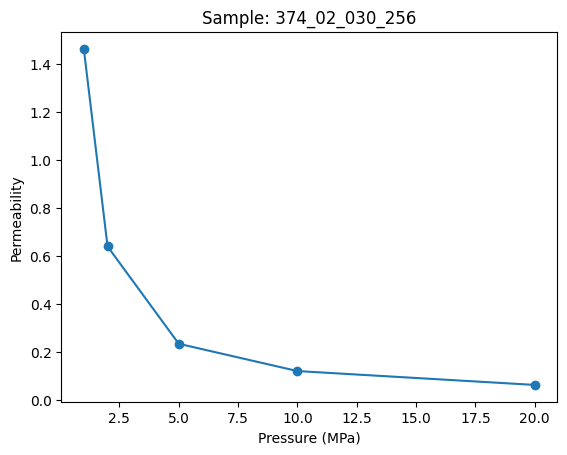

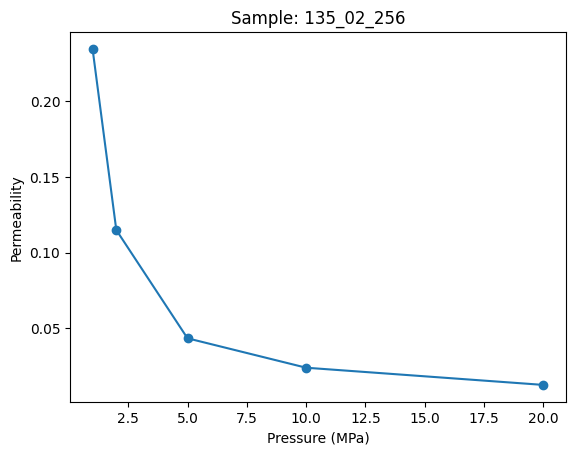

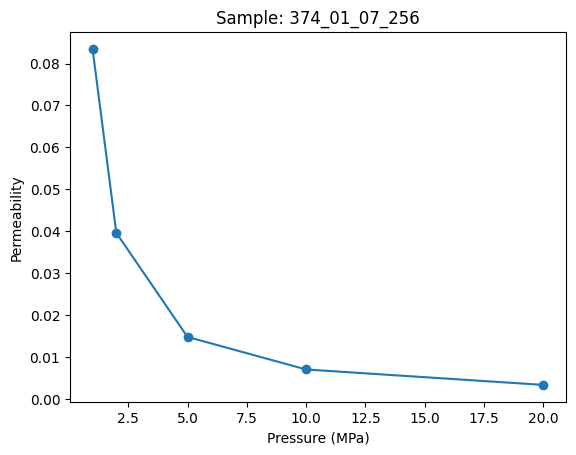

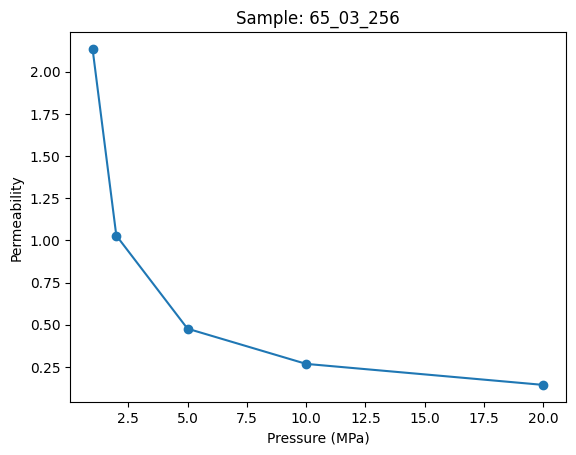

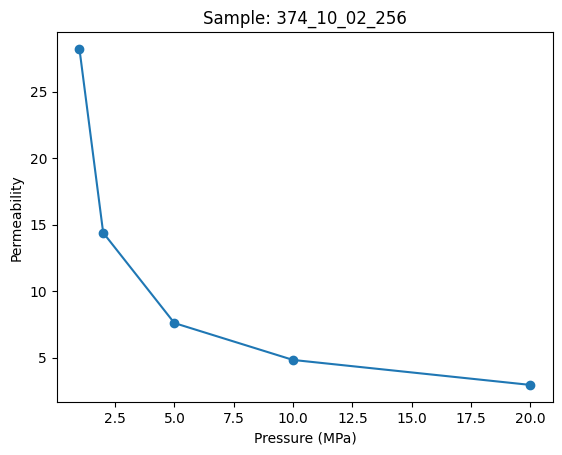

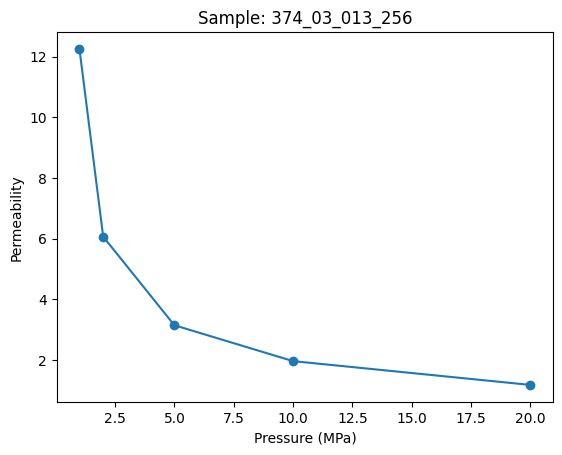

In [11]:
# @title
import matplotlib.pyplot as plt

for _, i in df.sample(6).iterrows():
  perms = i[pressure_cols].values.astype(float)
  plt.plot(pressure_values, perms, 'o-')
  plt.title(f"Sample: {i['sample']}")
  plt.xlabel("Pressure (MPa)")
  plt.ylabel("Permeability")
  plt.show()

In [12]:
# @title Заполним наны благодаря такой зависимости

def fill_permeability_gaps(df, visualize=True, n_plots=4, random_state=42, fill_lbm=True, lbm_factor=1e-12):
    """
    Заполняет пропуски в значениях проницаемости.
    - Удаляет образцы, где полностью отсутствуют данные (все колонки NaN).
    - Если известна только одна точка – заполняет все пропуски этим значением.
    - Если известны 2+ точки и есть положительные – подгоняет степенную зависимость.
    - При неудаче подгонки заполняет средним известных.
    - Отрицательные значения заменяются на NaN (они не должны были остаться после чистки, но на всякий случай).
    """
    pressures = np.array([1, 2, 5, 10, 20], dtype=float)
    perm_cols = [f'perm_{int(p)}MPa' for p in pressures]

    # 1. Удаляем строки, где вообще нет данных по проницаемостям
    mask_all_nan = df[perm_cols].isna().all(axis=1)
    df = df[~mask_all_nan].copy()
    if mask_all_nan.sum() > 0:
        print(f"Удалено полностью пустых образцов: {mask_all_nan.sum()}")

    df_filled = df.copy()
    samples_with_fills = []

    def power_law(P, a, b):
        return a * np.power(P, b)

    for idx, row in df_filled.iterrows():
        values = pd.to_numeric(row[perm_cols], errors='coerce').to_numpy(dtype=float)
        # Отрицательные и нулевые превращаем в NaN, чтобы не ломали подгонку
        values = np.where(values <= 0, np.nan, values)
        valid_mask = ~np.isnan(values)
        P_valid = pressures[valid_mask]
        k_valid = values[valid_mask]
        n_valid = len(P_valid)

        # Если после замены отрицательных на NaN не осталось данных – пропускаем
        if n_valid == 0:
            continue

        had_fill = False

        if n_valid == 1:
            fill_value = k_valid[0]
            for i, col in enumerate(perm_cols):
                if pd.isna(row[col]) or row[col] <= 0:  # исходный NaN или отрицательный
                    df_filled.at[idx, col] = fill_value
                    had_fill = True
        else:
            # Подгонка по положительным значениям (отрицательных уже нет после замены)
            try:
                logP = np.log(P_valid)
                logK = np.log(k_valid)
                coeffs = np.polyfit(logP, logK, 1)
                a = np.exp(coeffs[1])
                b = coeffs[0]
                k_pred = power_law(pressures, a, b)

                for i, col in enumerate(perm_cols):
                    if pd.isna(row[col]) or row[col] <= 0:
                        df_filled.at[idx, col] = k_pred[i]
                        had_fill = True
            except Exception:
                mean_val = k_valid.mean()
                for i, col in enumerate(perm_cols):
                    if pd.isna(row[col]) or row[col] <= 0:
                        df_filled.at[idx, col] = mean_val
                        had_fill = True

        if had_fill:
            samples_with_fills.append(idx)

    # Заполняем perm_LBM
    if fill_lbm and 'perm_LBM' in df_filled.columns:
        for idx, row in df_filled.iterrows():
            if pd.isna(row['perm_LBM']):
                perm_20 = df_filled.at[idx, 'perm_20MPa']
                if not pd.isna(perm_20):
                    df_filled.at[idx, 'perm_LBM'] = perm_20 * lbm_factor

    if visualize and samples_with_fills:
        np.random.seed(random_state)
        selected = np.random.choice(samples_with_fills,
                                    size=min(n_plots, len(samples_with_fills)),
                                    replace=False)

        for idx in selected:
            row_original = df.loc[idx]   # до заполнения (уже без полностью пустых)
            row_filled = df_filled.loc[idx]

            orig_vals = pd.to_numeric(row_original[perm_cols], errors='coerce').to_numpy(dtype=float)
            mask_known = ~np.isnan(orig_vals) & (orig_vals > 0)
            P_known = pressures[mask_known]
            k_known = orig_vals[mask_known]

            filled_vals = row_filled[perm_cols].to_numpy(dtype=float)
            mask_filled = np.isnan(orig_vals) | (orig_vals <= 0)
            P_filled = pressures[mask_filled]
            k_filled = filled_vals[mask_filled]

            plt.figure(figsize=(10, 5))
            plt.plot(P_known, k_known, 'o', color='blue', markersize=8, label='Исходные')
            if len(P_filled) > 0:
                plt.plot(P_filled, k_filled, 's', color='red', markersize=8, label='Заполненные')
            plt.title(f"Образец: {row_original['sample']}")
            plt.xlabel("Эффективное давление, МПа")
            plt.ylabel("Проницаемость")
            plt.grid(True, linestyle=':', alpha=0.6)
            plt.legend()
            plt.show()

    print(f"Обработано образцов: {len(df_filled)}. Заполнены пропуски в {len(samples_with_fills)} образцах.")
    return df_filled

filled_df = fill_permeability_gaps(df)


Удалено полностью пустых образцов: 6
Обработано образцов: 127. Заполнены пропуски в 0 образцах.


Пропуски заполнены, обновим датасет

In [13]:
filled_df.isna().sum()

,0
index,0
sample,0
rock_type,0
perm_1MPa,0
perm_2MPa,0
perm_5MPa,0
perm_10MPa,0
perm_20MPa,0
perm_LBM,0


In [14]:
# @title

filled_df.to_csv("dataset_combined.csv", index=False)
print(f"Обновлённый файл dataset_combined.csv сохранён.")

csv_dir = "data/csv"
pressures = ['1', '2', '5', '10', '20', 'LBM']
col_map = {
    '1': 'perm_1MPa',
    '2': 'perm_2MPa',
    '5': 'perm_5MPa',
    '10': 'perm_10MPa',
    '20': 'perm_20MPa',
    'LBM': 'perm_LBM'
}

for _, row in filled_df.iterrows():
    sample_name = row['sample']
    csv_file = os.path.join(csv_dir, f"{sample_name}.csv")

    data = []
    for p in pressures:
        col = col_map[p]
        if col in row.index:
            val = row[col]
            if pd.notna(val):
                data.append({'pressure': p, 'permeability': val})

    if data:
        sample_df = pd.DataFrame(data)
        sample_df.to_csv(csv_file, index=False)
        print(f"Обновлён: {csv_file}")
    else:
        print(f"Пропущен (нет данных): {sample_name}")

print("Все файлы обновлены.")

dataset = PermeabilityDataset()


Обновлённый файл dataset_combined.csv сохранён.
Обновлён: data/csv/10_01_256.csv
Обновлён: data/csv/135_00_256.csv
Обновлён: data/csv/135_02_256.csv
Обновлён: data/csv/135_03_256.csv
Обновлён: data/csv/135_04_256.csv
Обновлён: data/csv/16_01_256.csv
Обновлён: data/csv/16_02_256.csv
Обновлён: data/csv/172_01_256.csv
Обновлён: data/csv/172_02_256.csv
Обновлён: data/csv/172_03_256.csv
Обновлён: data/csv/204_010_256.csv
Обновлён: data/csv/204_011_256.csv
Обновлён: data/csv/204_012_256.csv
Обновлён: data/csv/204_01_256.csv
Обновлён: data/csv/204_02_256.csv
Обновлён: data/csv/204_03_256.csv
Обновлён: data/csv/204_04_256.csv
Обновлён: data/csv/204_05_256.csv
Обновлён: data/csv/204_07_256.csv
Обновлён: data/csv/204_08_256.csv
Обновлён: data/csv/204_09_256.csv
Обновлён: data/csv/207_01_256.csv
Обновлён: data/csv/207_03_256.csv
Обновлён: data/csv/207_04_256.csv
Обновлён: data/csv/276_01_256.csv
Обновлён: data/csv/297_01_256.csv
Обновлён: data/csv/317_010_256.csv
Обновлён: data/csv/317_011_256.cs

In [15]:
dataset[124]

(tensor([[[[1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           ...,
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.]],
 
          [[1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           ...,
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.]],
 
          [[1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           ...,
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.],
           [1., 1., 1.,  ..., 0., 0., 0.]],
 
          ...,
 
          [[0., 0., 0.,  ..., 1., 1., 1.],
           [0., 0., 0.,  ..., 1., 1., 1.],
           [0., 0., 0.,  ..., 1., 1., 1.],
           ...,
       

# Фильтрация бинарных рисунков
Фнкции фильтрации позволяют покрасить пустоты в
 градиент, что в дальнейшем позволит делать градацию серого и считать персистентные гомологии.

## Функция визуализации породы
Данная функция позволяет отрисовать изображение породы по трехмерному бинарному массиву данных

In [16]:
# @title visualize

def visualize(data, sample_name='rock_structure_1', substance_name = "rock_1",
              L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid = pv.ImageData(dimensions=shape, spacing=(1, 1, 1), origin=(0, 0, 0))
    grid.point_data["values"] = data_np.flatten(order="F")

    # Генерация изоповерхности (максимальное количество полигонов на входе)
    surface_mesh = grid.contour([0.5], scalars="values")

    # Агрессивное уменьшение количества полигонов (Decimation)
    if decimation_factor > 0 and surface_mesh.n_cells > 0:
        surface_mesh = surface_mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Рисуем границы куба
    plotter.add_mesh(surface_mesh, color='grey', lighting=True) ## smooth_shading=True добавлять?
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', line_width=1, opacity=0.5) # добавляем границы

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L
    plotter.add_title(substance_name, font_size=10)  # название камня

    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del surface_mesh
    del grid

    if T:
      display(Image(img_path))

In [17]:
# @title visualize_color_rock, _pore, _all, _binary

def visualize_color_rock(data, filtration_vol, file_name='rock_structure_colored',
                         L = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, decimation_factor=0.9, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Записываем маску породы и значения фильтрации в данные ячеек (cell_data)
    grid.cell_data["rock_mask"] = data_np.flatten(order="F").astype(np.uint8)
    grid.cell_data["dist_value"] = filt_np.flatten(order="F")

    # Переносим данные из ячеек в точки (point_data), так как алгоритм contour работает с точками
    grid = grid.cell_data_to_point_data()

    # Создаем полигональную сетку (изоповерхность) на границе пора/порода (значение 0.5)
    mesh = grid.contour([0.5], scalars="rock_mask")

    # Уменьшаем количество полигонов для ускорения отрисовки, если задан коэффициент
    if decimation_factor > 0 and mesh.n_cells > 0:
        mesh = mesh.decimate(decimation_factor)

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Добавляем сетку в визуализатор, раскрашивая по значениям фильтрации, убираем шкалу
    if "dist_value" in mesh.point_data:
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)
    else:
        # Если данные потерялись при децимации, интерполируем их заново
        mesh = mesh.sample(grid)
        plotter.add_mesh(mesh, scalars="dist_value", cmap="jet", lighting=True, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(pv.Cube(bounds=[0, shape[0]-1, 0, shape[1]-1, 0, shape[2]-1]),
                     style='wireframe', color='black', opacity=0.5)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del mesh
    del grid

    if T:
      display(Image(img_path))


def visualize_color_pore(data, filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    vis_values = np.where(data_np == 1, filt_np, -0.1)
    grid.cell_data["colors"] = vis_values.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Создаем модифицированный jet
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('jet_with_grey', new_colors)

    plotter.add_mesh(faces, scalars="colors", cmap=custom_cmap,
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_all(filtration_vol, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    filt_np = np.flip(filtration_vol.squeeze(), axis=0)
    shape = filt_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))


    grid.cell_data["colors"] = filt_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    plotter.add_mesh(faces, scalars="colors", cmap='jet',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def visualize_color_binary(data, file_name='pore_cube_faces',
                         L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    data_np = np.flip(data.squeeze(), axis=0)
    shape = data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Если порода (data == 0), присваиваем -0.1 для серого цвета
    grid.cell_data["colors"] = data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')


    plotter.add_mesh(faces, scalars="colors", cmap=ListedColormap(['#6a6863', 'white']),
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = L

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{file_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))

In [18]:
# @title Функции отрисовки срезов
def show_slice(data, k=128, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = data.squeeze()[:, :, k]

    if not T:
      return slice_2d

    # Визуализация среза
    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=ListedColormap(['#6a6863', 'white'])) #  0-серый (порода), 1-белый (поры)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_pore(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где порода (data == 0), ставим -0.1 для серого цвета
    vis_volume = np.where(data.squeeze() == 1, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d


    # Создаем копию jet, но добавляем цвет #6a6863 для породы
    jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
    new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_rock(data, normalized_grad, k=128, axis = 'z', T = True):
    # Применяем маску: там где поры (data == 1), ставим -0.1 для белого цвета
    vis_volume = np.where(data.squeeze() == 0, normalized_grad.squeeze(), -0.1)

    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    # Создаем копию jet, но для пор устанавливаем белый цвет
    base_cmap = plt.get_cmap('jet')
    new_colors = base_cmap(np.linspace(0, 1, 256))
    custom_cmap = LinearSegmentedColormap.from_list('custom_jet_rock', new_colors)
    custom_cmap.set_under('white')

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap=custom_cmap)
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def show_slice_filtered_all(normalized_grad, k=128, axis = 'z', T = True):
    vis_volume = normalized_grad.squeeze()
    if axis == 'z':
      # Извлекаем срез по оси z
      slice_2d = vis_volume[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      slice_2d = vis_volume[k, :, :]
    else:
      # Извлекаем срез по оси y
      slice_2d = vis_volume[:, :, k]

    if not T:
      return slice_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(slice_2d, cmap='jet')
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()

In [19]:
# @title show_filtration, show_filtration_small

def show_filtration(data, filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    data=data.squeeze()
    filt=filt.squeeze()
    visualize(data, sample_name, substance_name, camera_position, False)
    visualize_color_rock(data, filt, f'rock_{sample_name}', camera_position, False)
    visualize_color_pore(data, filt, f'pore_{sample_name}', camera_position, False)

    # Создаем общую фигуру 4x3
    fig = plt.figure(figsize=(18, 24))

    # заголовок
    fig.text(0.15, 0.91, f"Образец: {sample_name}", fontsize=20, va='center')

    # шкала min max
    sm = plt.cm.ScalarMappable(cmap='jet', norm=plt.Normalize(vmin=0, vmax=1))
    cax = fig.add_axes([0.42, 0.90, 0.53, 0.015])
    cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
    cb.set_label('Filtration values', labelpad=-75, fontsize=18)
    cb.set_ticks([0, 1])
    cb.set_ticklabels(['min', 'max'], fontsize=18)

    # 3D визуализация
    paths = [f'/tmp/{sample_name}.png', f'/tmp/rock_{sample_name}.png', f'/tmp/pore_{sample_name}.png']
    for i, path in enumerate(paths):
        ax = fig.add_subplot(4, 3, i + 1)
        img = mpimg.imread(path)
        ax.imshow(img)
        ax.axis('off')


    for i, k in enumerate(levels):
        row_idx = i + 1

        # Колонка 1: show_slice
        ax_bin = fig.add_subplot(4, 3, row_idx * 3 + 1)
        ax_bin.imshow(data[:, k, :] if axis == 'z' else (data[k, :, :] if axis == 'x' else data[:, :, k]), cmap=ListedColormap(['#6a6863', 'white']))
        ax_bin.axis('off')
        ax_bin.text(-0.05, 0.5, f"{axis} = {k}", transform=ax_bin.transAxes,
                    rotation='vertical', va='center', ha='right', fontsize=16)

        # Колонка 2: show_slice_filtered_rock
        ax_rock = fig.add_subplot(4, 3, row_idx * 3 + 2)
        ax_rock.imshow(filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k]), cmap='jet')
        ax_rock.axis('off')

        # Колонка 3: show_slice_filtered_pore
        ax_pore = fig.add_subplot(4, 3, row_idx * 3 + 3)
        vis_pore = np.where(data == 1, filt, -0.1)
        jet_colors = plt.get_cmap('jet')(np.linspace(0, 1, 256))
        new_colors = np.vstack([np.array([106/255, 104/255, 99/255, 1.0]), jet_colors])
        custom_cmap = LinearSegmentedColormap.from_list('custom_jet', new_colors)
        ax_pore.imshow(vis_pore[:, k, :] if axis == 'z' else (vis_pore[k, :, :] if axis == 'x' else vis_pore[:, :, k]), cmap=custom_cmap)
        ax_pore.axis('off')

    # Настраиваем отступы вручную, чтобы убрать пустоту справа
    plt.subplots_adjust(left=0.08, right=0.98, top=0.88, bottom=0.05, wspace=0.05, hspace=0.1)
    plt.show()


def show_filtration_small(filt, sample_name='rock_1', substance_name = "rock_1", axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    # Предварительная генерация 3D скриншотов
    filt=filt.squeeze()

    visualize_color_all(filt, f'all_{sample_name}', camera_position, False)

    # Создаем общую фигуру
    fig, ax = plt.subplots(nrows=1, ncols=1 + len(levels), figsize=(10 + len(levels), 18))
    #fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)



    img_all = mpimg.imread(f'/tmp/all_{sample_name}.png')
    ax[0].imshow(img_all)
    ax[0].set_title(f'{substance_name} \n {sample_name}' )
    ax[0].axis('off')

    for i, k in enumerate(levels):
        ax_idx = i + 1
        # Показываем срезы на оставшихся осях
        slice_img = filt[:, k, :] if axis == 'z' else (filt[k, :, :] if axis == 'x' else filt[:, :, k])
        ax[ax_idx].imshow(slice_img, cmap='jet')
        ax[ax_idx].set_title(f"{axis}={k}")
        ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.show()

## Общие параметры

In [20]:
# # @title

# n = 1
# vol_tensor, target, sample_name = dataset[n]
# data = 1 - vol_tensor.squeeze().numpy().astype(np.uint8)



# print(f'Имя файла {sample_name}, размер {data.shape}')
# print(f'Пористость породы {int(np.sum(data)) / 256**3}') # 1 - поры, 0 - породы
# print(target)
# visualize(data, sample_name, dataset.get_rock_type(sample_name))

## Функции фильтраций

In [32]:
# @title Height filtration

def apply_height_filtration(data, normal=(0, 0, 1), d=0):
    L = []
    for i in data:
        L.append(apply_height_filtration_one(i, normal, d))
    return np.array(L)


def apply_height_filtration_one(data, normal=(0, 0, 1), d=0):
    shape = data.shape
    # Создаем сетку координат, центрированную относительно центра куба
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    z_c, y_c, x_c = z - (shape[0] // 2 - 1), y - (shape[0] // 2 - 1), x - (shape[0] // 2 - 1)

    # Нормируем вектор нормали
    n = np.array(normal) / np.linalg.norm(normal)

    # Вычисляем расстояние от каждой точки до плоскости
    dist_from_plane = x_c * n[0] + y_c * n[1] + z_c * n[2] - d
    filtration_values = np.abs(dist_from_plane)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values


In [33]:
#@title Radial filtration
def apply_radial_filtration(data, p=None):
    L = []
    for i in data:
        L.append(apply_radial_filtration_one(i, p))
    return np.array(L)

def apply_radial_filtration_one(data, p=None):
    shape = data.shape

    if p is None:
        p = (shape[0]//2, shape[1]//2, shape[2]//2)

    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]

    # Вычисляем квадраты расстояний от центра p для каждой оси
    dist_sq = (x - p[0])**2 + (y - p[1])**2 + (z - p[2])**2
    filtration_values = np.sqrt(dist_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)

    return filtration_values

In [34]:
# @title Line filtration

def apply_line_filtration(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    L = []
    for i in data:
        L.append(apply_line_filtration_one(i, p1, p2))
    return np.array(L)


def apply_line_filtration_one(data, p1=(0, 0, 0), p2=(255, 255, 255)):
    shape = data.shape
    # Создаем сетку координат
    z, y, x = np.ogrid[:shape[0], :shape[1], :shape[2]]
    p1 = np.array(p1)
    p2 = np.array(p2)

    # Векторы от p1 до всех точек сетки
    dx, dy, dz = x - p1[0], y - p1[1], z - p1[2]

    # Направляющий вектор прямой (p2 - p1) и его норма
    v = p2 - p1
    v_norm_sq = np.sum(v**2) + 1e-9

    # Расстояние от точки до прямой
    cross_x = dy * v[2] - dz * v[1]
    cross_y = dz * v[0] - dx * v[2]
    cross_z = dx * v[1] - dy * v[0]

    filtration_values = np.sqrt((cross_x**2 + cross_y**2 + cross_z**2) / v_norm_sq)
    M=filtration_values.max()
    filtration_values = np.where(data == 1, filtration_values, M)


    return filtration_values

In [35]:
# @title Функции фильтраций из библиотеки giotto-tda и подключение кастомных

#HeightFiltration
HF = HeightFiltration(direction=np.array([0, 1, 1])) # [z, x, y]
height_filt_gt= HF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#RadialFiltration
RF = RadialFiltration(np.array([127, 127, 127])) # [z, x, y]
radial_filt_gt = RF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DensityFiltration
DeF = DensityFiltration()
density_filt_gt= DeF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#DilationFiltration
DiF = DilationFiltration()
dilation_filt_gt= DiF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#ErosionFiltration
EF = ErosionFiltration()
erosion_filt_gt= EF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


#SignedDistanceFiltration
SDF = SignedDistanceFiltration()
signed_distence_filt_gt = SDF.fit_transform(data[np.newaxis, :, :, :]).astype(np.float32)


# Кастомные фильтрации
height_filt = apply_height_filtration(data[np.newaxis, :, :, :], normal=(1, 1, 1), d=100).astype(np.float32)
line_filt = apply_line_filtration(data[np.newaxis, :, :, :], (127, 127, 127), (255, 255, 255)).astype(np.float32)

TypeError: list indices must be integers or slices, not tuple

## Функции визуализаций фильтраций

In [26]:
# @title Визуализация фильтраций

# print(f"Форма входных данных: {data[np.newaxis, :, :, :].shape}")

# fig, ax = plt.subplots(ncols=2, figsize=(10, 10))

# visualize(data, sample_name, dataset.get_rock_type(sample_name), L=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T=False)
# visualize_color_binary(data, f'binary_{sample_name}', [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], False)

# img = mpimg.imread(f'/tmp/{sample_name}.png')
# ax[0].imshow(img)
# ax[0].axis('off')

# img_bin = mpimg.imread(f'/tmp/binary_{sample_name}.png')
# ax[1].imshow(img_bin)
# ax[1].axis('off')

# plt.show()

# # Отображаем результат
# print("Height Filtration giotto-tda")
# print(f'min: {height_filt_gt.min()}, max: {height_filt_gt.max()}')
# show_filtration_small(height_filt_gt, f"{sample_name}_height_gt", dataset.get_rock_type(sample_name))

# print("Radial Filtration giotto-tda")
# print(f'min: {radial_filt_gt.min()}, max: {radial_filt_gt.max()}')
# show_filtration_small(radial_filt_gt, f"{sample_name}_radial_gt", dataset.get_rock_type(sample_name))

# print("Density Filtration giotto-tda")
# print(f'min: {density_filt_gt.min()}, max: {density_filt_gt.max()}')
# show_filtration_small(density_filt_gt, f"{sample_name}_density_gt", dataset.get_rock_type(sample_name))

# print("Dilation Filtration giotto-tda")
# print(f'min: {dilation_filt_gt.min()}, max: {dilation_filt_gt.max()}')
# show_filtration_small(dilation_filt_gt, f"{sample_name}_dilation_gt", dataset.get_rock_type(sample_name))

# print("Erosion Filtration giotto-tda")
# print(f'min: {erosion_filt_gt.min()}, max: {erosion_filt_gt.max()}')
# show_filtration_small(erosion_filt_gt, f"{sample_name}_erosion_gt", dataset.get_rock_type(sample_name))

# print("Signed Distence Filtration giotto-tda")
# print(f'min: {signed_distence_filt_gt.min()}, max: {signed_distence_filt_gt.max()}')
# show_filtration_small(signed_distence_filt_gt, f"{sample_name}_signed_distence_gt", dataset.get_rock_type(sample_name))

# # Визуализация кастомных фильтраций
# print("Height Filtration custom")
# print(f'min: {height_filt.min()}, max: {height_filt.max()}')
# show_filtration_small(height_filt, f"{sample_name}_height", dataset.get_rock_type(sample_name))

# print("Line Filtration custom")
# print(f'min: {line_filt.min()}, max: {line_filt.max()}')
# show_filtration_small(line_filt, f"{sample_name}_line", dataset.get_rock_type(sample_name))


# Визуализация кубического комплекса
В этом разделе мы считаем персистентные диаграммы при помощи методов библиотеки GUDHI для уже отфильтрованных в предыдущем разделе массивов, а также визуализуруем кибические комплексы разными способами.

## Визуализация в сером

In [ ]:
# @title Функции визуализации grayscale

def show_slice_grayscale(grad_data, k=40, axis = 'z', T = True):
    if axis == 'z':
      # Извлекаем срез по оси z
      grayscale_2d = grad_data.squeeze()[:, k, :]
    elif axis == 'x':
      # Извлекаем срез по оси x
      grayscale_2d = grad_data.squeeze()[k, :, :]
    else:
      # Извлекаем срез по оси y
      grayscale_2d = grad_data.squeeze()[:, :, k]

    if not T:
      return grayscale_2d

    plt.figure(figsize=(8, 8))
    plt.imshow(grayscale_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
    plt.title(f"Срез {axis} = {k}")
    plt.axis('off')
    plt.show()


def visualize_grayscale_faces(grad_data, sample_name='grayscale_pore_cube_faces',
                         camera_position=[(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)], T = True, window_size=[635, 635]):
    grad_data_np = np.flip(grad_data.squeeze(), axis=0)
    shape = grad_data_np.shape

    # Создаем сетку
    grid_shape = (shape[0] + 1, shape[1] + 1, shape[2] + 1)
    grid = pv.ImageData(dimensions=grid_shape, spacing=(1,1,1))

    # Добавляем данные в сетку
    grid.cell_data["colors"] = grad_data_np.flatten(order="F")

    # Настройка визуализатора
    pv.set_jupyter_backend('static')
    plotter = pv.Plotter(off_screen=True, window_size=window_size)

    # Извлекаем только внешние грани куба
    outline = grid.outline()
    faces = grid.extract_surface(algorithm='dataset_surface')

    # Теперь массив 'colors' существует в данных поверхности
    plotter.add_mesh(faces, scalars="colors", cmap='gray',
                     lighting=False, show_scalar_bar=False)

    # Рисуем границы куба
    plotter.add_mesh(outline, color="black", line_width=1)

    # Настройка фона и положения камеры
    plotter.set_background('white')
    plotter.camera_position = camera_position

    # Сохраняем скриншот и отображаем его в ноутбуке
    img_path = f'/tmp/{sample_name}.png'
    plotter.screenshot(img_path)

    # Закрываем плоттер и очищаем память
    plotter.close()
    del plotter
    del faces
    del grid

    if T:
      display(Image(img_path))


def show_grayscale_small(grayscale_filt, sample_name='rock_1', substance_name = "rock_1", filt_name = 'filtration_name', axis = 'z', levels = [0, 127, 255],
                    camera_position = [(-300, 350, -500), (128, 128, 128), (1, 0, 1.5)]):
    grayscale_filt=grayscale_filt.squeeze()
    visualize_grayscale_faces(grayscale_filt, f'multipl_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)


    fig, ax = plt.subplots(ncols= 1 + len(levels), figsize=(10 + len(levels), 18))

    ax[0].imshow(mpimg.imread(f'/tmp/multipl_{small_sample_name}.png'))
    ax[0].set_title(filt_name)
    ax[0].axis('off')

    for i, k in enumerate(levels):
          ax_idx = i + 1
          slice_img = grayscale_filt[:, k, :] if axis == 'z' else (grayscale_filt[k, :, :] if axis == 'x' else grayscale_filt[:, :, k])
          ax[ax_idx].imshow(slice_img, cmap='gray')
          ax[ax_idx].set_title(f"{axis}={k}")
          ax[ax_idx].axis('off')

    plt.tight_layout()
    plt.subplots_adjust(wspace=0.05, hspace=-0.43)
    plt.show()

In [ ]:
# @title Кубик 85 на 85 на 85
grayscale_filt = line_filt[:, :85, :85, :85] # значения от 0 до 1 #:85, 85:170, 171:256
grayscale_data = 1-vol_tensor.numpy()[:, :85, :85, :85] # 0 - порода, 1 - поры
small_sample_name = f'{sample_name}_111_radial'


# # Передаем уровни (levels), которые не превышают размер 85
# print(grayscale_filt.shape)
# print(grayscale_data.shape)
# show_filtration(grayscale_data, grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])
# show_filtration_small(grayscale_filt, small_sample_name, dataset.get_rock_type(sample_name), levels=[0, 40, 84], camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

NameError: name 'line_filt' is not defined

In [ ]:
# # @title Визуализация фильтраций в сером

# # меньшие числа соответсвуют более темным точка, болшие - более светлым.
# show_grayscale_small(radial_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'radial_gt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# show_grayscale_small(signed_distence_filt_gt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'signed_distence_gt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])

# show_grayscale_small(line_filt[:, :85, :85, :85], small_sample_name, dataset.get_rock_type(sample_name), 'line_filt', levels = [0, 40, 84],
#                      camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)])


## Кубический комплекс

In [ ]:
# # @title Функции визуализации кубического комплекса
# def show_cubical_complex_slice(img_filtered, k=42, axis = 'z', num_thresholds = 10):
#     if axis == 'z':
#       # Извлекаем срез по оси z
#       slice_2d = img_filtered.squeeze()[:, k, :]
#     elif axis == 'x':
#       # Извлекаем срез по оси x
#       slice_2d = img_filtered.squeeze()[k, :, :]
#     else:
#       # Извлекаем срез по оси y
#       slice_2d = img_filtered.squeeze()[:, :, k]

#     v_min = np.min(slice_2d)
#     v_max = np.max(slice_2d)
#     fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

#     ax[0].imshow(slice_2d, cmap='gray') # gray 0 -> черный, 1 -> белый
#     ax[0].set_title(f"{axis} = {k}")
#     ax[0].axis('off')

#     for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)): # 20 порогов от 0 до 1
#         ax[i+1].axis("off")
#         ax[i+1].imshow(slice_2d <= t, cmap='gray_r', vmin=0, vmax=1)
#         ax[i+1].set_title(f"{t:.2f}")
#     plt.tight_layout()
#     plt.show()


# def visualize_cubical_complex_faces(img_filtered, num_thresholds = 10, title = 'cubical_complex', title_2 = "filt"):
#       v_min = np.min(img_filtered)
#       v_max = np.max(img_filtered)
#       v_min = v_min + (v_max - v_min) / num_thresholds
#       fig, ax = plt.subplots(ncols=num_thresholds + 1, figsize=(num_thresholds + 1, 11), dpi=300)

#       visualize_grayscale_faces(img_filtered, f'cubical_complex_pore_{small_sample_name}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
#       ax[0].imshow(mpimg.imread(f'/tmp/{title}.png'))
#       ax[0].set_title(title_2, fontsize = 10)
#       ax[0].axis('off')

#       for i, t in enumerate(np.linspace(v_min, v_max, num_thresholds)):
#           vis_values = np.where(img_filtered <= t, 0, 1)
#           visualize_grayscale_faces(vis_values, f'{title}_{i+1}', camera_position = [(-100, 150, -200), (42, 42, 42), (1, 0, 1.5)], T = False)
#           ax[i+1].imshow(mpimg.imread(f'/tmp/{title}_{i+1}.png'))
#           ax[i+1].set_title(f"{t:.2f}")
#           ax[i+1].axis("off")
#       plt.tight_layout()
#       plt.show()

In [ ]:
# # @title
# show_cubical_complex_slice(grayscale_filt[0], 84, num_thresholds = 20)
# visualize_cubical_complex_faces(grayscale_filt[0], 20, title = f'cubical_complex_pore_{small_sample_name}', title_2 = title)




# Эйлеровы Кривые

Напишем функцию, которая создает направления на сфере: по заданному количеству полярных и азимутных углов, она делит отрезок от 0 до \pi (или 2\pi для азимутного) на равные части и для каждой пары (полярный, азимутный) отмечает точку на сфере. Так как распределение на отрезках равномерное, то и на сфере тоже будет равномерным.

In [16]:
def generate_spherical_grid_directions(
    num_thetas: int, num_phis: int, d: int = 3
) -> torch.Tensor:

    assert d == 3
    theta = torch.linspace(0, torch.pi, num_thetas + 2)[1:-1] #полярный от 0 до 180
    phi = torch.linspace(0, 2 * torch.pi, num_phis + 1)[:-1] #азимутный от 0 до 360

    phi_grid, theta_grid = torch.meshgrid(phi, theta, indexing="ij")
    sin_theta = torch.sin(theta_grid)
    #переходим в сферические координаты
    x = sin_theta * torch.cos(phi_grid)
    y = sin_theta * torch.sin(phi_grid)
    z = torch.cos(theta_grid)
    dirs = torch.stack([x, y, z], dim=0)
    dirs = dirs.reshape(3, -1)
    return dirs

Для наглядности визуализируем (возьмем 4 полярных и 4 азимутных):

In [17]:
def visualize_directions_3d(directions, title="Directions on Sphere"):

    dirs_np = directions.cpu().numpy()

    fig = plt.figure(figsize=(12, 10))
    ax = fig.add_subplot(111, projection='3d')

    u = np.linspace(0, 2 * np.pi, 100)
    v = np.linspace(0, np.pi, 100)
    x_sphere = np.outer(np.cos(u), np.sin(v))
    y_sphere = np.outer(np.sin(u), np.sin(v))
    z_sphere = np.outer(np.ones(np.size(u)), np.cos(v))
    ax.plot_wireframe(x_sphere, y_sphere, z_sphere, color='gray', alpha=0.2, linewidth=0.5)

    scatter = ax.scatter(dirs_np[0], dirs_np[1], dirs_np[2],
                         c='red', s=80, alpha=0.8, edgecolors='black', linewidth=0.5)

    for i in range(dirs_np.shape[1]):
        ax.plot([0, dirs_np[0, i]], [0, dirs_np[1, i]], [0, dirs_np[2, i]],
                'b-', alpha=0.3, linewidth=0.5)

    ax.set_xlabel('X', fontsize=12)
    ax.set_ylabel('Y', fontsize=12)
    ax.set_zlabel('Z', fontsize=12)
    ax.set_title(f'{title}\n{dirs_np.shape[1]} directions', fontsize=14)
    ax.set_box_aspect([1, 1, 1])

    plt.tight_layout()
    plt.show()

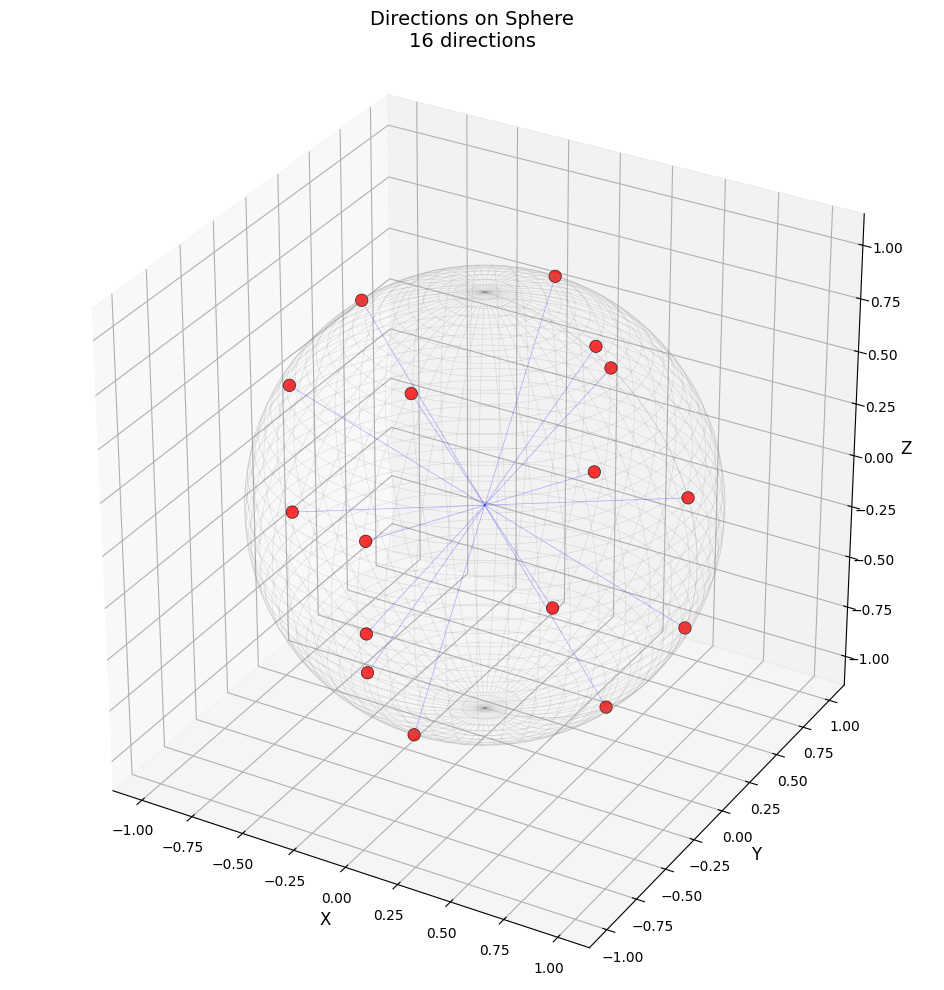

In [18]:
dirs=generate_spherical_grid_directions(4,4,3)
visualize_directions_3d(dirs)

In [19]:
class OptimizedDECTLayer(nn.Module):
    def __init__(self, num_thetas=4, num_phis=4, n_steps=16, scale=500.0):
        super().__init__()
        self.num_thetas = num_thetas
        self.num_phis = num_phis
        self.n_directions = num_thetas * num_phis
        self.n_steps = n_steps
        self.scale = scale

        fixed_directions = generate_spherical_grid_directions(num_thetas, num_phis)
        self.register_buffer('directions', fixed_directions)
        self.register_buffer('thresholds', torch.linspace(-1.5, 1.5, n_steps))

    def extract_pore_coords(self, volume):
        batch_size = volume.shape[0]
        device = volume.device
        coords_list = []

        for b in range(batch_size):
            pore_mask = (volume[b, 0] > 0.5)
            indices = torch.nonzero(pore_mask, as_tuple=False).float()

            if len(indices) > 0:
                indices = (indices - 127.5) / 127.5 #нормализуем
                coords_list.append(indices)
            else:
                coords_list.append(torch.zeros((0, 3), device=device))

        return coords_list

    def forward(self, volume):
        batch_size = volume.shape[0]
        device = volume.device

        coords_list = self.extract_pore_coords(volume)
        thresholds = self.thresholds.view(-1, 1, 1)

        ect_batch = []

        for b in range(batch_size):
            coords = coords_list[b]

            if len(coords) == 0:
                ect_batch.append(torch.zeros(self.n_directions, self.n_steps, device=device))
                continue

            # проблемы с памятью --- пор слишком много (примерно 3 миллиона, изначально брала 8*8=64 направления, итого примерно 27gb памяти)
            # поэтому будем обрабатывать частями по 200к пор (примерно 17 частей, на каждую памяти хватает, после все суммируем)
            if len(coords) > 500000:
                chunk_size = 200000
                n_chunks = (len(coords) + chunk_size - 1) // chunk_size

                ecc_sum = torch.zeros(self.n_steps, self.n_directions, device=device)

                for i in range(n_chunks):
                    start = i * chunk_size
                    end = min((i + 1) * chunk_size, len(coords))
                    coords_chunk = coords[start:end]

                    heights = coords_chunk @ self.directions
                    diff = thresholds - heights.unsqueeze(0)
                    indicator = torch.sigmoid(self.scale * diff)
                    ecc_sum += indicator.sum(dim=1)

                ect_batch.append(ecc_sum.T)
            else:
                heights = coords @ self.directions
                diff = thresholds - heights.unsqueeze(0)
                indicator = torch.sigmoid(self.scale * diff)
                ecc = indicator.sum(dim=1)
                ect_batch.append(ecc.T)

        return torch.stack(ect_batch)

In [20]:
'''Старый не работал, так как были проблемы с памятью
class DECTLayer(nn.Module):
    def __init__(self, num_thetas=8, num_phis=8, n_steps=32, scale=500.0):

        super().__init__()
        self.num_thetas = num_thetas
        self.num_phis = num_phis
        self.n_directions = num_thetas * num_phis
        self.n_steps = n_steps
        self.scale = scale

        fixed_directions = generate_spherical_grid_directions(num_thetas, num_phis)
        self.register_buffer('directions', fixed_directions)

        self.register_buffer(
            'thresholds',
            torch.linspace(-1.5, 1.5, n_steps)
        )

    def extract_pore_coords(self, volume):

        batch_size = volume.shape[0]
        device = volume.device
        coords_list = []

        for b in range(batch_size):
            pore_mask = (volume[b, 0] > 0.5)
            indices = torch.nonzero(pore_mask, as_tuple=False).float()

            if len(indices) > 0:
                indices = (indices - 127.5) / 127.5
                coords_list.append(indices)
            else:
                coords_list.append(torch.zeros((0, 3), device=device))

        return coords_list

    def forward(self, volume):
        batch_size = volume.shape[0]
        device = volume.device

        coords_list = self.extract_pore_coords(volume)

        thresholds = self.thresholds.view(-1, 1, 1)

        ect_batch = []

        for b in range(batch_size):
            coords = coords_list[b]

            if len(coords) == 0:

                ect_batch.append(
                    torch.zeros(self.n_directions, self.n_steps, device=device)
                )
                continue

            heights = coords @ self.directions #проецируем на направления

            diff = thresholds - heights.unsqueeze(0)
            indicator = torch.sigmoid(self.scale * diff)

            ecc = indicator.sum(dim=1)  #считаем кривые по всем направлениям

            ect_batch.append(ecc.T)

        return torch.stack(ect_batch)


SyntaxError: incomplete input (3417929640.py, line 1)

In [21]:
def test_dect_on_sample(sample_idx=0):
    vol, perm, name = dataset[sample_idx]
    print(f"\nОбразец: {name}")
    print(f"Форма объема: {vol.shape}")
    pore_fraction = (vol > 0.5).float().mean().item()
    print(f"Пористость: {pore_fraction:.4f}")
    print(f"Проницаемость (LBM): {perm[5].item():.2e}")

    dect = OptimizedDECTLayer(num_thetas=4, num_phis=4, n_steps=16, scale=500.0)
    with torch.no_grad():
        vol_batch = vol.unsqueeze(0)
        ect = dect(vol_batch)

    print(f"\nECT shape: {ect.shape}")
    print(f"ECT min: {ect.min().item():.4f}")
    print(f"ECT max: {ect.max().item():.4f}")
    print(f"ECT mean: {ect.mean().item():.4f}")

    return dect, ect, name, perm

In [23]:
def visualize_single_ecc(ect, direction_idx=0):
    ecc = ect[0, direction_idx, :].cpu().numpy()
    thresholds = np.linspace(-1.5, 1.5, len(ecc))

    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(thresholds, ecc, 'b-', linewidth=2, marker='o', markersize=3)
    ax.fill_between(thresholds, 0, ecc, alpha=0.3)

    ax.set_xlabel('Порог', fontsize=12)
    ax.set_ylabel('Эйлерова характеристика', fontsize=12)
    ax.set_title(f'ECC для направления {direction_idx}', fontsize=14)
    ax.grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    return ecc




In [24]:
def visualize_all_ecc(ect, num_directions_to_show=8):

    thresholds = np.linspace(-1.5, 1.5, ect.shape[2])
    n_directions = min(num_directions_to_show, ect.shape[1])

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    axes = axes.flatten()

    colors = plt.cm.tab10(np.linspace(0, 1, n_directions))

    for i in range(n_directions):
        ecc = ect[0, i, :].cpu().numpy()
        axes[i].plot(thresholds, ecc, color=colors[i], linewidth=2)
        axes[i].fill_between(thresholds, 0, ecc, alpha=0.2, color=colors[i])
        axes[i].set_xlabel('Порог')
        axes[i].set_ylabel('ECC')
        axes[i].set_title(f'Направление {i}')
        axes[i].grid(True, alpha=0.3)
        axes[i].set_ylim(bottom=0)

    plt.suptitle('Эйлеровы кривые для разных направлений', fontsize=16)
    plt.tight_layout()
    plt.show()

Тестируем:

In [25]:
vol, perm, name = dataset[0]
print(f"Sample: {name}")
print(f"Volume shape: {vol.shape}")

dect = OptimizedDECTLayer(num_thetas=4, num_phis=4, n_steps=16)

with torch.no_grad():
    vol_batch = vol.unsqueeze(0)
    ect = dect(vol_batch)

print(f"ECT shape: {ect.shape}")


Sample: 10_01_256
Volume shape: torch.Size([1, 256, 256, 256])
ECT shape: torch.Size([1, 16, 16])



Образец: 10_01_256
Форма объема: torch.Size([1, 256, 256, 256])
Пористость: 0.9133
Проницаемость (LBM): 1.72e-14

ECT shape: torch.Size([1, 16, 16])
ECT min: 0.0000
ECT max: 15322256.0000
ECT mean: 7661128.0000


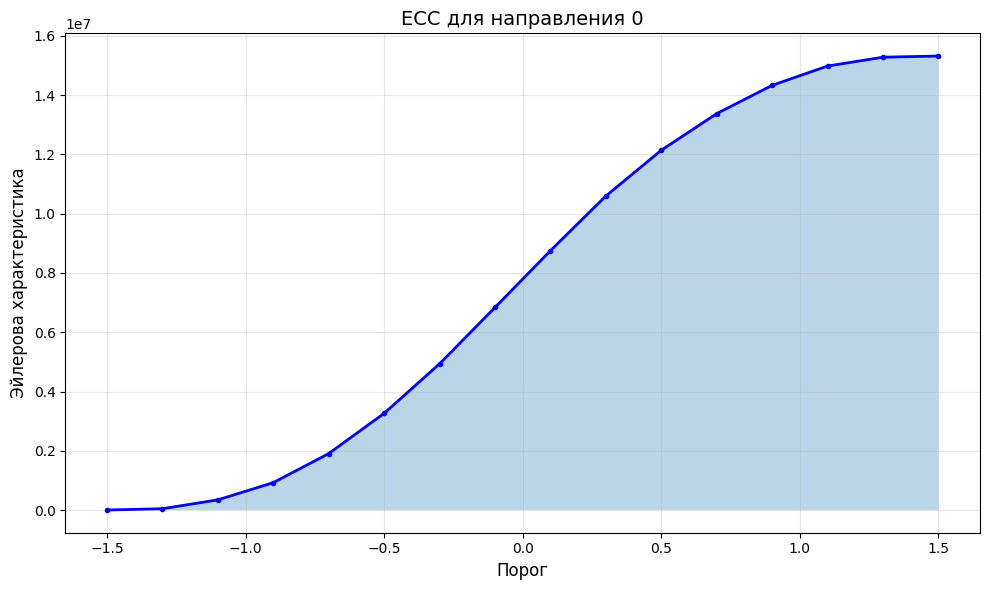

array([       0.  ,    44096.27,   343339.75,   923527.3 ,  1905058.4 ,  3262386.2 ,  4934510.5 ,  6837148.  ,
        8752931.  , 10597643.  , 12142338.  , 13378747.  , 14333608.  , 14984134.  , 15283202.  , 15322256.  ],
      dtype=float32)

In [26]:
    dect, ect, name, perm = test_dect_on_sample(sample_idx=0)
    visualize_single_ecc(ect, direction_idx=0)

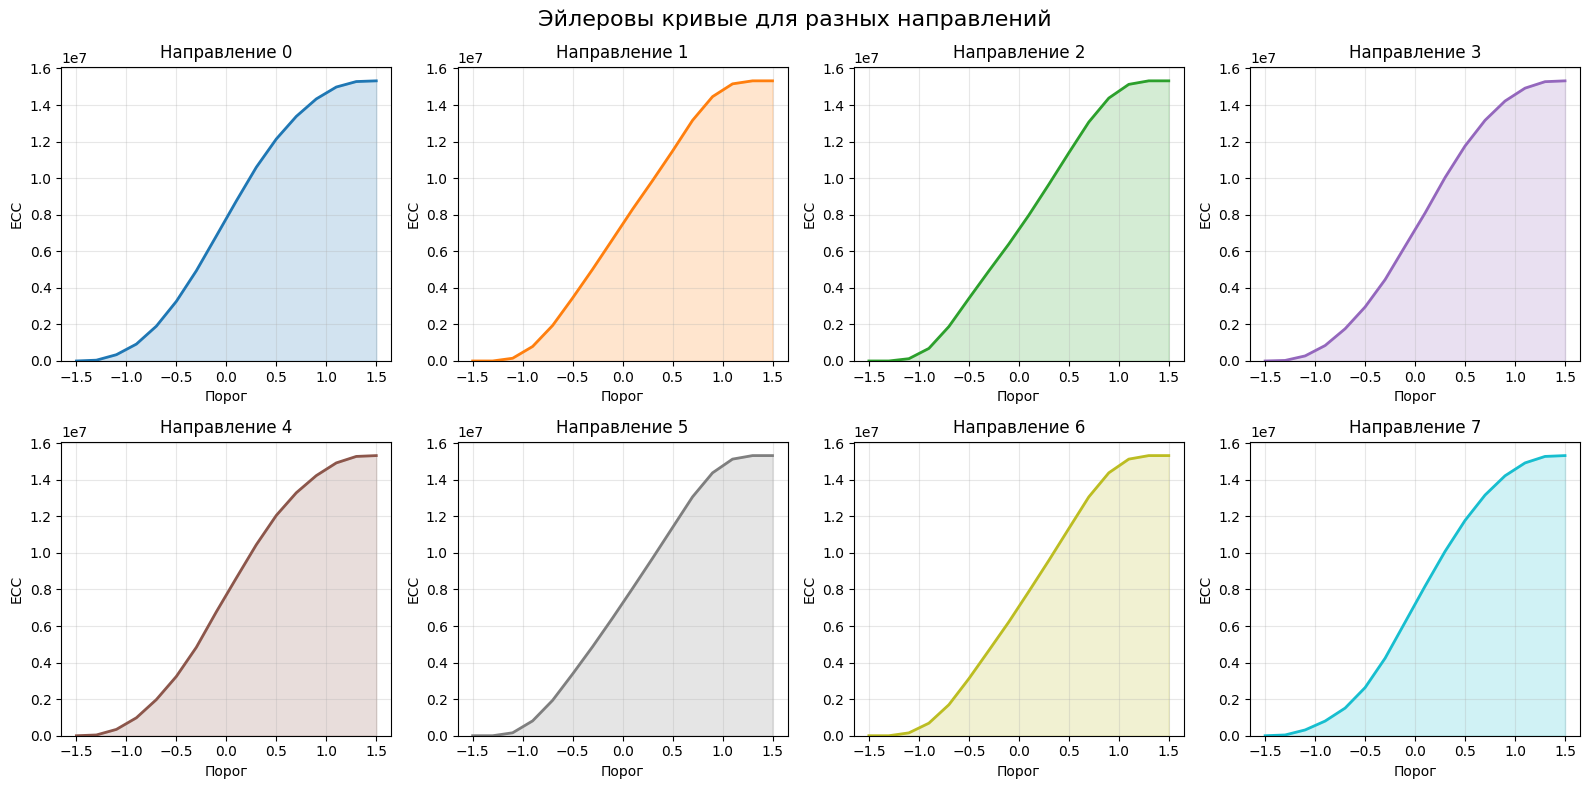

In [27]:
visualize_all_ecc(ect, num_directions_to_show=8)

Видимо пора по всем направлениям выглядит +- одинаково... Это проблема?

In [28]:
class OptimizedPermeabilityDECTModel(nn.Module):
    def __init__(self, num_thetas=4, num_phis=4, n_steps=16, n_pressures=6):
        super().__init__()
        self.dect = OptimizedDECTLayer(
            num_thetas=num_thetas,
            num_phis=num_phis,
            n_steps=n_steps
        )

        n_directions = num_thetas * num_phis
        self.conv_layers = nn.Sequential(
            nn.Conv2d(1, 8, kernel_size=3, padding=1),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.Conv2d(8, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.AdaptiveAvgPool2d((4, 4)),
            nn.Flatten(),
            nn.Linear(16 * 4 * 4, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, n_pressures)
        )

    def forward(self, volume):
        ect = self.dect(volume)
        ect = ect.unsqueeze(1)
        permeability = self.conv_layers(ect)
        return permeability




In [29]:
def train_model(model, train_loader, val_loader, num_epochs=50, lr=0.001, device='cuda'):
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-5)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=10)
    criterion = nn.MSELoss()

    history = {'train_loss': [], 'val_loss': []}
    best_val_loss = float('inf')

    for epoch in range(num_epochs):
        model.train()
        train_loss = 0
        for vol, perm, _ in tqdm(train_loader, desc=f"Epoch {epoch+1}"):
            vol = vol.to(device)
            perm = perm.to(device)

            optimizer.zero_grad()
            pred = model(vol)
            loss = criterion(pred, perm)
            loss.backward()
            optimizer.step()
            train_loss += loss.item()

        model.eval()
        val_loss = 0
        with torch.no_grad():
            for vol, perm, _ in val_loader:
                vol = vol.to(device)
                perm = perm.to(device)
                pred = model(vol)
                loss = criterion(pred, perm)
                val_loss += loss.item()

        train_loss /= len(train_loader)
        val_loss /= len(val_loader)

        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), 'best_model.pth')

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}: Train Loss = {train_loss:.6f}, Val Loss = {val_loss:.6f}")

    return model, history


def prepare_dataloaders(dataset, batch_size=2, train_ratio=0.7, val_ratio=0.15):
    n_train = int(train_ratio * len(dataset))
    n_val = int(val_ratio * len(dataset))
    n_test = len(dataset) - n_train - n_val

    train_dataset, val_dataset, test_dataset = random_split(
        dataset, [n_train, n_val, n_test]
    )

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    print(f"Train: {n_train}, Val: {n_val}, Test: {n_test}")

    return train_loader, val_loader, test_loader


def plot_training_history(history):
    fig, ax = plt.subplots(figsize=(10, 6))

    ax.plot(history['train_loss'], label='Train Loss', linewidth=2)
    ax.plot(history['val_loss'], label='Val Loss', linewidth=2)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE Loss')
    ax.set_title('Training History')
    ax.legend()
    ax.grid(True, alpha=0.3)
    ax.set_yscale('log')

    plt.tight_layout()
    plt.show()


def evaluate_model(model, test_loader, device='cuda'):
    model.eval()
    all_preds = []
    all_targets = []

    with torch.no_grad():
        for vol, perm, _ in test_loader:
            vol = vol.to(device)
            perm = perm.to(device)
            pred = model(vol)
            all_preds.append(pred.cpu())
            all_targets.append(perm.cpu())

    all_preds = torch.cat(all_preds, dim=0)
    all_targets = torch.cat(all_targets, dim=0)

    mse = ((all_preds - all_targets) ** 2).mean().item()
    mae = torch.abs(all_preds - all_targets).mean().item()
    r2_scores = []
    for i in range(6):
        ss_res = ((all_preds[:, i] - all_targets[:, i]) ** 2).sum()
        ss_tot = ((all_targets[:, i] - all_targets[:, i].mean()) ** 2).sum()
        r2 = 1 - ss_res / (ss_tot + 1e-8)
        r2_scores.append(r2.item())

    print(f"Test Results:")
    print(f"MSE: {mse:.6f}")
    print(f"MAE: {mae:.6f}")
    print(f"R² by pressure:")
    pressures = ['1MPa', '2MPa', '5MPa', '10MPa', '20MPa', 'LBM']
    for i, (p, r2) in enumerate(zip(pressures, r2_scores)):
        print(f"{p}: {r2:.4f}")



def run_training(dataset, num_epochs=10, batch_size=2, lr=0.001,
                 num_thetas=4, num_phis=4, n_steps=16):

    import gc
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()

    print(f"Параметры обучения:")
    print(f"  Epochs: {num_epochs}")
    print(f"  Batch size: {batch_size}")
    print(f"  Learning rate: {lr}")
    print(f"  Directions: {num_thetas*num_phis}")
    print(f"  Thresholds: {n_steps}")

    model = OptimizedPermeabilityDECTModel(
        num_thetas=num_thetas,
        num_phis=num_phis,
        n_steps=n_steps,
        n_pressures=6
    )

    n_params = sum(p.numel() for p in model.parameters())

    train_loader, val_loader, test_loader = prepare_dataloaders(
        dataset, batch_size=batch_size
    )

    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    trained_model, history = train_model(
        model, train_loader, val_loader,
        num_epochs=num_epochs,
        lr=lr,
        device=device
    )
    metrics = evaluate_model(trained_model, test_loader, device=device)

    return trained_model, history, metrics



In [30]:
test_vol, test_perm, _ = dataset[0]
test_model = OptimizedPermeabilityDECTModel(num_thetas=4, num_phis=4, n_steps=16)
with torch.no_grad():
    pred = test_model(test_vol.unsqueeze(0))

In [31]:
trained_model, history, metrics = run_training(dataset)

Параметры обучения:
  Epochs: 10
  Batch size: 2
  Learning rate: 0.001
  Directions: 16
  Thresholds: 16
Train: 93, Val: 19, Test: 21


Epoch 1:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 4:   0%|          | 0/47 [00:00<?, ?it/s]

...

Epoch 7:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 8:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 9:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10:   0%|          | 0/47 [00:00<?, ?it/s]

Epoch 10: Train Loss = 22.702849, Val Loss = 111.789830
Test Results:
MSE: 77.094574
MAE: 5.856812
R² by pressure:
1MPa: -4.2177
2MPa: -6.2889
5MPa: -8.9634
10MPa: -11.7126
20MPa: -19.9300
LBM: -5555825.0000


# Эксперименты с разными методами вычисления ПД

## Функции подсчёта

In [ ]:
# @title Вычисление ПД через cripser

def compute_diagrams_cripser(filtration):
    raw = cripser.computePH(filtration, maxdim=2)
    points = raw[:, [1, 2, 0]].copy()
    points[points[:, 1] > 1e300, 1] = np.inf

    return points

In [ ]:
# @title Вычисление ПД через GUDHI

def gudhi_to_array(diagram):
    a = np.array([[birth, death, dim] for (dim, (birth, death)) in diagram])
    return a


def compute_gudhi_dg(data_cube, noise = 0):
    cc = gd.CubicalComplex(dimensions=data_cube.shape, top_dimensional_cells=data_cube.flatten())
    return gudhi_to_array(cc.persistence(min_persistence=noise))

In [ ]:
# @title Визуализация персистентных диграмм.

# height_filt_gt, radial_filt_gt, density_filt_gt, dilation_filt_gt, erosion_filt_gt, signed_distence_filt_gt, height_filt, line_filt


grayscale_filt = signed_distence_filt_gt[:, :85, :85, :85]
title = 'signed_distence_gt'

print(grayscale_filt.min(), grayscale_filt.max(), title)

# Расчет через GUDHI
t0 = time.time()
diag_gd = compute_gudhi_dg(grayscale_filt[0])
t1 = time.time()
print(f"Время расчета персистентной диаграммы (GUDHI): {t1-t0:.4f} секунд")

# Визуализация
fig = plot_diagram(diag_gd)
fig.show()

# Расчет через cripser
t0 = time.time()
diag_cripser = compute_diagrams_cripser(grayscale_filt[0])
t1 = time.time()
print(f"Время расчета персистентной диаграммы (cripser): {t1-t0:.4f} секунд")

# Визуализация
fig = plot_diagram(diag_cripser)
fig.show()

# Подсчёт ПД для всего датасета

### Общие функции обработки

In [ ]:
# @title Функция вычисления ПД

def compute_diagrams_cripser(filtration):
    raw = cripser.computePH(filtration, maxdim=2)
    points = raw[:, [1, 2, 0]].copy()
    points[points[:, 1] > 1e300, 1] = np.inf

    return points

In [ ]:
#@title Служебная функция ограничения выделенной на процесс памяти
def limit_memory(n):
    limit = n * 1024**3
    resource.setrlimit(resource.RLIMIT_AS, (limit, limit))

In [ ]:
#@title Функция подсчёта ПД для определенного образца с определенной фильтрацией
def process_sample(filt_name, sample_name, sample_path, output_dir, n):
    mem_before = get_current_memory()
    limit_memory(n)
    output_path = os.path.join(output_dir, f"{sample_name}_{filt_name}_pd.pkl")

    if os.path.exists(output_path):
        return 0

    cube = np.load(sample_path)
    grayscale = FILTRATIONS[filt_name](cube)
    points = compute_diagrams_cripser(grayscale)


    with open(output_path, 'wb') as f:
        pickle.dump({
            'sample': sample_name,
            'filtration': filt_name,
            'diagrams': points
        }, f)
    mem_mid = get_current_memory()

    del cube, grayscale, points
    mem_after = get_current_memory()
    print(f"Task {i} | Before: {mem_before:.2f}GB | Mid: {mem_mid:.2f}GB | After: {mem_after:.2f}GB")
    return 1

In [ ]:
#@title Функция подсчёта ПД для всего датасета
def process_dataset(filt, ds, output_dir, n_memory, n_processes):
  tasks = [
    (filt_name, name, os.path.join("data/npy", f"{name}.npy"), output_dir, n_memory)
    for _, _, name in ds
    for filt_name in filt
  ]
  with tqdm(total=len(tasks), desc="Вычисление ПД", unit="задача") as pbar:
    for _ in Parallel(n_jobs=n_processes)(delayed(process_sample)(*task) for task in tasks):
         pbar.update(1)

In [ ]:
#@title Функция выгрузки данных во внешний архив

def download_zip(source_dir, output_zip):
    with zipfile.ZipFile(output_zip, 'w', zipfile.ZIP_DEFLATED) as zipf:
        for root, dirs, filenames in os.walk(source_dir):
            for filename in filenames:
                file_path = os.path.join(root, filename)
                arcname = os.path.relpath(file_path, os.path.dirname(source_dir))
                zipf.write(file_path, arcname)

    print(f"Архив создан: {output_zip}")
    print(f"Размер: {os.path.getsize(output_zip) / 1024**2:.1f} MB")

    # Скачиваем
    files.download(output_zip)

### Обработка радиальных фильтраций

In [27]:
# @title Словарь всех конфигураций радиальных фильтраций (27 штук)

FILTRATIONS_RADIAL = {}

# 3×3×3 = 27 радиальных фильтраций
for i in range(3):
    for j in range(3):
        for k in range(3):
            name = f'radial_{i}_{j}_{k}'
            FILTRATIONS_RADIAL[name] = (
                lambda data, i=i, j=j, k=k: apply_radial_filtration_one(
                    data,
                    p=(
                        data.shape[0] // 4 * (i + 1),
                        data.shape[1] // 4 * (j + 1),
                        data.shape[2] // 4 * (k + 1)
                    )
                )
            )

In [29]:
#@title Обработка радиальных фильтраций
output_dir = "persistent_diagrams_radial"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_RADIAL, dataset, output_dir, n_memory, n_processes)
download_zip(source_dir, output_zip)

NameError: name 'process_dataset' is not defined

In [ ]:
#@title Визуализация центров радиальных фильтраций

def plot_radial_centers(shape=(256, 256, 256)):
    """
    Визуализация центров 27 радиальных фильтраций (жирные точки)
    и объёмного куба с сеткой на гранях (шаг 64).
    """
    fig = plt.figure(figsize=(7, 6))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    # Максимальные индексы (0..255)
    Lx, Ly, Lz = shape[2] - 1, shape[1] - 1, shape[0] - 1

    # ---------- Центры радиальных фильтраций (27 точек) ----------
    # i,j,k ∈ {0,1,2} → координаты 64, 128, 192
    centers_x = [shape[2] // 4 * (i + 1) for i in range(3)]
    centers_y = [shape[1] // 4 * (j + 1) for j in range(3)]
    centers_z = [shape[0] // 4 * (k + 1) for k in range(3)]

    for x in centers_x:
        for y in centers_y:
            for z in centers_z:
                ax.scatter(x, y, z,
                           c='red', s=80, edgecolors='black',
                           linewidth=1.5, alpha=0.9)

    # ---------- Каркас куба ----------
    corners = np.array([[0, 0, 0], [1, 0, 0], [1, 1, 0], [0, 1, 0],
                        [0, 0, 1], [1, 0, 1], [1, 1, 1], [0, 1, 1]])
    edges = [(0, 1), (1, 2), (2, 3), (3, 0),
             (4, 5), (5, 6), (6, 7), (7, 4),
             (0, 4), (1, 5), (2, 6), (3, 7)]
    for e1, e2 in edges:
        ax.plot([corners[e1][0] * Lx, corners[e2][0] * Lx],
                [corners[e1][1] * Ly, corners[e2][1] * Ly],
                [corners[e1][2] * Lz, corners[e2][2] * Lz],
                'k-', linewidth=1.5)

    # ---------- Сетка на гранях с шагом 64 ----------
    def get_grid_coords(max_val):
        coords = list(range(0, max_val + 1, 64))
        if coords[-1] != max_val:
            coords.append(max_val)
        return coords

    grid_x = get_grid_coords(Lx)
    grid_y = get_grid_coords(Ly)
    grid_z = get_grid_coords(Lz)

    def draw_grid_face(fixed_coord, axis):
        if axis == 'x':  # плоскость YZ
            for y in grid_y:
                ax.plot([fixed_coord, fixed_coord], [y, y], [0, Lz],
                        color='gray', alpha=0.3, linewidth=0.5)
            for z in grid_z:
                ax.plot([fixed_coord, fixed_coord], [0, Ly], [z, z],
                        color='gray', alpha=0.3, linewidth=0.5)
        elif axis == 'y':  # плоскость XZ
            for x in grid_x:
                ax.plot([x, x], [fixed_coord, fixed_coord], [0, Lz],
                        color='gray', alpha=0.3, linewidth=0.5)
            for z in grid_z:
                ax.plot([0, Lx], [fixed_coord, fixed_coord], [z, z],
                        color='gray', alpha=0.3, linewidth=0.5)
        else:  # 'z' – плоскость XY
            for x in grid_x:
                ax.plot([x, x], [0, Ly], [fixed_coord, fixed_coord],
                        color='gray', alpha=0.3, linewidth=0.5)
            for y in grid_y:
                ax.plot([0, Lx], [y, y], [fixed_coord, fixed_coord],
                        color='gray', alpha=0.3, linewidth=0.5)

    for x in (0, Lx):
        draw_grid_face(x, 'x')
    for y in (0, Ly):
        draw_grid_face(y, 'y')
    for z in (0, Lz):
        draw_grid_face(z, 'z')

    # Деления на осях
    ax.set_xticks(grid_x)
    ax.set_yticks(grid_y)
    ax.set_zticks(grid_z)

    ax.set_xlim(0, Lx)
    ax.set_ylim(0, Ly)
    ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title('Centers')
    plt.tight_layout()
    plt.show()

plot_radial_centers()

### Обработка линейных фильтраций

In [ ]:
# @title Словарь всех конфигураций линейных фильтраций (36 штук)

FILTRATIONS_LINE = {}

# ---------- 1. Осевые фильтрации (12 штук) ----------
axial_params = [
    ('X1', 0.5, 0.25, 0.25), ('X2', 0.5, 0.25, 0.75), ('X3', 0.5, 0.75, 0.25), ('X4', 0.5, 0.75, 0.75),
    ('Y1', 0.25, 0.5, 0.25), ('Y2', 0.25, 0.5, 0.75), ('Y3', 0.75, 0.5, 0.25), ('Y4', 0.75, 0.5, 0.75),
    ('Z1', 0.25, 0.25, 0.5), ('Z2', 0.25, 0.75, 0.5), ('Z3', 0.75, 0.25, 0.5), ('Z4', 0.75, 0.75, 0.5),
]

for name, rx, ry, rz in axial_params:
    if 'X' in name:
        v = (1, 0, 0)
    elif 'Y' in name:
        v = (0, 1, 0)
    else:
        v = (0, 0, 1)
    FILTRATIONS_LINE[f'line_{name}'] = (
        lambda data, rx=rx, ry=ry, rz=rz, v=v: apply_line_filtration_one(
            data,
            p1=(int((data.shape[2]-1)*rx), int((data.shape[1]-1)*ry), int((data.shape[0]-1)*rz)),
            p2=(int((data.shape[2]-1)*rx)+v[0], int((data.shape[1]-1)*ry)+v[1], int((data.shape[0]-1)*rz)+v[2])
        )
    )

# ---------- 2. Диагональные фильтрации (24 штуки) ----------
for i in (-1, 1):
    for j in (-1, 1):
        for k in (-1, 1):
            FILTRATIONS_LINE[f'line_diag1_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2),
                    p2=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k)
                )
            )
            FILTRATIONS_LINE[f'line_diag2_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k),
                    p2=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2)
                )
            )
            FILTRATIONS_LINE[f'line_diag3_{i}_{j}_{k}'] = (
                lambda data, i=i, j=j, k=k: apply_line_filtration_one(
                    data,
                    p1=((data.shape[2]-1)//2,
                         (data.shape[1]-1)//2 + (data.shape[1]-1)//4 * j,
                         (data.shape[0]-1)//2 + (data.shape[0]-1)//4 * k),
                    p2=((data.shape[2]-1)//2 + (data.shape[2]-1)//4 * i,
                         (data.shape[1]-1)//2,
                         (data.shape[0]-1)//2)
                )
            )

In [ ]:
#@title Обработка линейных фильтраций
output_dir = "persistent_diagrams_line"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_LINE, dataset, output_dir, n_memory, n_processes)
download_zip(source_dir, output_zip)

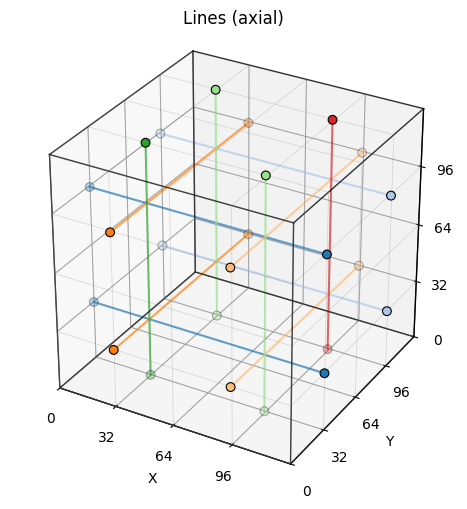

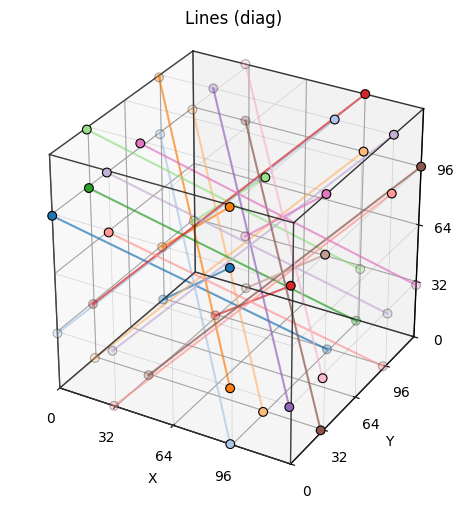

In [ ]:
#@title Визуализация осей линейных фильтраций

def plot_line_through_points(ax, p1, p2, limits, color, cnt):
    """
    Рисует прямую, заданную двумя точками p1 и p2, пересекающую куб,
    и жирные точки на границах.
    limits = (Lx, Ly, Lz) – максимальные координаты (размер-1).
    color – цвет линии и точек.
    cnt – нужен для согласованности, возвращает обновлённый счётчик (не используется).
    """
    Lx, Ly, Lz = limits
    v = np.array(p2, dtype=float) - np.array(p1, dtype=float)
    v_norm = v / np.linalg.norm(v)

    # Найдём параметры t для всех шести граней
    t_candidates = []
    # x = 0
    if v[0] != 0:
        t = (0 - p1[0]) / v[0]
        y = p1[1] + t * v[1]
        z = p1[2] + t * v[2]
        if 0 <= y <= Ly and 0 <= z <= Lz:
            t_candidates.append(t)
    # x = Lx
    if v[0] != 0:
        t = (Lx - p1[0]) / v[0]
        y = p1[1] + t * v[1]
        z = p1[2] + t * v[2]
        if 0 <= y <= Ly and 0 <= z <= Lz:
            t_candidates.append(t)
    # y = 0
    if v[1] != 0:
        t = (0 - p1[1]) / v[1]
        x = p1[0] + t * v[0]
        z = p1[2] + t * v[2]
        if 0 <= x <= Lx and 0 <= z <= Lz:
            t_candidates.append(t)
    # y = Ly
    if v[1] != 0:
        t = (Ly - p1[1]) / v[1]
        x = p1[0] + t * v[0]
        z = p1[2] + t * v[2]
        if 0 <= x <= Lx and 0 <= z <= Lz:
            t_candidates.append(t)
    # z = 0
    if v[2] != 0:
        t = (0 - p1[2]) / v[2]
        x = p1[0] + t * v[0]
        y = p1[1] + t * v[1]
        if 0 <= x <= Lx and 0 <= y <= Ly:
            t_candidates.append(t)
    # z = Lz
    if v[2] != 0:
        t = (Lz - p1[2]) / v[2]
        x = p1[0] + t * v[0]
        y = p1[1] + t * v[1]
        if 0 <= x <= Lx and 0 <= y <= Ly:
            t_candidates.append(t)

    if len(t_candidates) < 2:
        # Прямая не пересекает куб (чего не должно быть), рисуем только отрезок p1-p2
        ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]], color=color, alpha=0.7)
        return

    t_min, t_max = min(t_candidates), max(t_candidates)
    pt_enter = np.array(p1) + t_min * v
    pt_exit = np.array(p1) + t_max * v

    # Рисуем линию
    ax.plot([pt_enter[0], pt_exit[0]], [pt_enter[1], pt_exit[1]], [pt_enter[2], pt_exit[2]],
            color=color, alpha=0.7)
    # Жирные точки на границах
    ax.scatter(*zip(pt_enter, pt_exit), c=[color], s=40, edgecolors='black', linewidth=0.8)

def plot_lines_by_type(shape=(128, 128, 128), line_type='axial', grid_step=32):
    """
    Визуализация линий: line_type = 'axial', 'diag' или 'all'.
    """
    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    Lx, Ly, Lz = shape[2]-1, shape[1]-1, shape[0]-1
    colors = plt.cm.tab20(np.linspace(0, 1, 36))
    cnt = 0

    # ---------- Осевые линии (12 шт.) ----------
    if line_type in ('axial', 'all'):
        dirs = {'X': (1,0,0), 'Y': (0,1,0), 'Z': (0,0,1)}
        for axis, v in dirs.items():
            if axis == 'X':
                pts = [(0.5,0.25,0.25),(0.5,0.25,0.75),(0.5,0.75,0.25),(0.5,0.75,0.75)]
            elif axis == 'Y':
                pts = [(0.25,0.5,0.25),(0.25,0.5,0.75),(0.75,0.5,0.25),(0.75,0.5,0.75)]
            else:
                pts = [(0.25,0.25,0.5),(0.25,0.75,0.5),(0.75,0.25,0.5),(0.75,0.75,0.5)]
            for (rx, ry, rz) in pts:
                pt = np.array([Lx * rx, Ly * ry, Lz * rz])
                v_arr = np.array(v, dtype=float)
                v_norm = v_arr / np.linalg.norm(v_arr)
                t_vals = []
                for i in range(3):
                    if v_norm[i] != 0:
                        t_vals.append((0 - pt[i]) / v_norm[i])
                        t_vals.append(([Lx, Ly, Lz][i] - pt[i]) / v_norm[i])
                t_min, t_max = min(t_vals), max(t_vals)
                p1 = pt + t_min * v_norm
                p2 = pt + t_max * v_norm
                ax.plot([p1[0], p2[0]], [p1[1], p2[1]], [p1[2], p2[2]],
                        color=colors[cnt], alpha=0.7)
                ax.scatter(*zip(p1, p2), c=[colors[cnt]], s=40, edgecolors='black', linewidth=0.8)
                cnt += 1

    # ---------- Диагональные линии (24 шт.) ----------
    if line_type in ('diag', 'all'):
        for i in (-1, 1):
            for j in (-1, 1):
                for k in (-1, 1):
                    # Набор 1
                    p1 = (Lx // 2 + Lx // 4 * i, Ly // 2 + Ly // 4 * j, Lz // 2)
                    p2 = (Lx // 2, Ly // 2, Lz // 2 + Lz // 4 * k)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1
                    # Набор 2
                    p1 = (Lx // 2 + Lx // 4 * i, Ly // 2, Lz // 2 + Lz // 4 * k)
                    p2 = (Lx // 2, Ly // 2 + Ly // 4 * j, Lz // 2)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1
                    # Набор 3
                    p1 = (Lx // 2, Ly // 2 + Ly // 4 * j, Lz // 2 + Lz // 4 * k)
                    p2 = (Lx // 2 + Lx // 4 * i, Ly // 2, Lz // 2)
                    plot_line_through_points(ax, p1, p2, (Lx, Ly, Lz), colors[cnt], cnt)
                    cnt += 1

    # Каркас и сетка
    corners = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,1],[1,0,1],[1,1,1],[0,1,1]])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    for e1,e2 in edges:
        ax.plot([corners[e1][0]*Lx, corners[e2][0]*Lx],
                [corners[e1][1]*Ly, corners[e2][1]*Ly],
                [corners[e1][2]*Lz, corners[e2][2]*Lz], 'k-', alpha=0.8, linewidth=1)

    grid_coords = np.arange(0, min(Lx, Ly, Lz)+1, grid_step)
    for z in (0, Lz):
        for x in grid_coords:
            ax.plot([x, x], [0, Ly], [z, z], color='gray', alpha=0.3, linewidth=0.5)
        for y in grid_coords:
            ax.plot([0, Lx], [y, y], [z, z], color='gray', alpha=0.3, linewidth=0.5)
    for y in (0, Ly):
        for x in grid_coords:
            ax.plot([x, x], [y, y], [0, Lz], color='gray', alpha=0.3, linewidth=0.5)
        for z in grid_coords:
            ax.plot([0, Lx], [y, y], [z, z], color='gray', alpha=0.3, linewidth=0.5)
    for x in (0, Lx):
        for y in grid_coords:
            ax.plot([x, x], [y, y], [0, Lz], color='gray', alpha=0.3, linewidth=0.5)
        for z in grid_coords:
            ax.plot([x, x], [0, Ly], [z, z], color='gray', alpha=0.3, linewidth=0.5)

    ax.set_xticks(np.arange(0, Lx+1, grid_step))
    ax.set_yticks(np.arange(0, Ly+1, grid_step))
    ax.set_zticks(np.arange(0, Lz+1, grid_step))
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Lines ({line_type})')
    plt.tight_layout()
    plt.show()

# Пример: раздельная визуализация
plot_lines_by_type(line_type='axial')
plot_lines_by_type(line_type='diag')

### Обработка плоскостных фильтраций

In [ ]:
# @title Словарь всех конфигураций плоскостных фильтраций (14 штук)


FILTRATIONS_HEIGHT = {}

# ---------- 1. Осевые плоскости (6 штук) ----------
center_x = (256 - 1) // 2
center_y = (256 - 1) // 2
center_z = (256 - 1) // 2
step = 256 // 4
# Нормали и расстояния для каждой из двух плоскостей на ось
axial_planes = [
    ('height_x1', (1, 0, 0), step - center_x),          # x = step
    ('height_x2', (1, 0, 0), 3 * step - center_x),      # x = 3*step
    ('height_y1', (0, 1, 0), step - center_y),          # y = step
    ('height_y2', (0, 1, 0), 3 * step - center_y),      # y = 3*step
    ('height_z1', (0, 0, 1), step - center_z),          # z = step
    ('height_z2', (0, 0, 1), 3 * step - center_z),      # z = 3*step
]

for name, normal, d in axial_planes:
    FILTRATIONS_HEIGHT[name] = (
        lambda data, normal=normal, d=d: apply_height_filtration_one(data, normal, d)
    )

# ---------- 2. Диагональные плоскости (8 штук) ----------
for s_x in (-1, 1):
    for s_y in (-1, 1):
        for s_z in (-1, 1):
            normal = (s_y * s_z, s_x * s_z, s_x * s_y)
            d = s_x * s_y * s_z * step
            signs = f"{'+' if s_x > 0 else '-'}{'+' if s_y > 0 else '-'}{'+' if s_z > 0 else '-'}"
            name = f'height_diag_{signs}'
            FILTRATIONS_HEIGHT[name] = (
                lambda data, normal=normal, d=d: apply_height_filtration_one(data, normal, d)
            )

In [ ]:
#@title Обработка плоскостных фильтраций
output_dir = "persistent_diagrams_line"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_HEIGHT, dataset, output_dir, n_memory, n_processes)
download_zip(source_dir, output_zip)

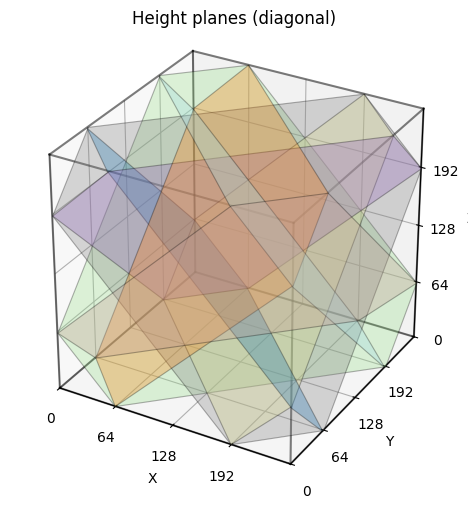

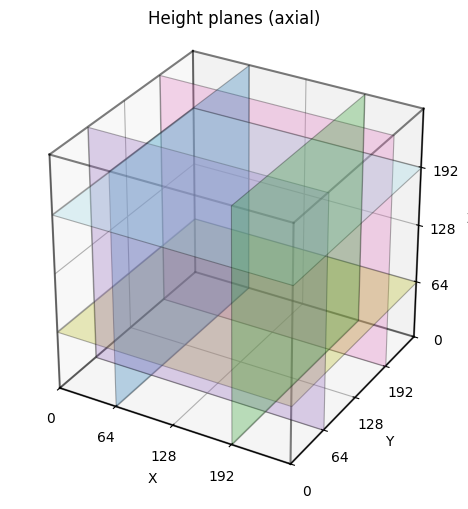

In [ ]:
#@title Визуализация плоскостей для фильтраций

def get_plane_cube_intersection(normal, d, center, cube_min=0, cube_max=255):
    """
    Возвращает вершины выпуклого многоугольника пересечения плоскости
    normal·(x - center) = d с кубом [cube_min, cube_max]^3.
    """
    n = np.asarray(normal)
    rhs = np.dot(n, center) + d

    corners = np.array([[x, y, z]
                        for x in (cube_min, cube_max)
                        for y in (cube_min, cube_max)
                        for z in (cube_min, cube_max)])
    edges = []
    for i in range(8):
        for j in range(i+1, 8):
            diff = corners[i] - corners[j]
            if np.count_nonzero(diff) == 1:
                edges.append((i, j))

    intersection_points = []
    for i, j in edges:
        p1 = corners[i]
        p2 = corners[j]
        d1 = np.dot(n, p1) - rhs
        d2 = np.dot(n, p2) - rhs
        if d1 * d2 < 0:
            t = -d1 / (d2 - d1)
            if 0 <= t <= 1:
                pt = p1 + t * (p2 - p1)
                intersection_points.append(pt)
    if len(intersection_points) < 3:
        return None
    pts = np.array(intersection_points)
    center_mass = pts.mean(axis=0)
    n_unit = n / np.linalg.norm(n)
    if np.abs(n_unit[0]) < 0.9:
        u1 = np.array([1, 0, 0])
    else:
        u1 = np.array([0, 1, 0])
    u1 = u1 - np.dot(u1, n_unit) * n_unit
    u1 = u1 / np.linalg.norm(u1)
    u2 = np.cross(n_unit, u1)
    proj = np.array([[np.dot(pt - center_mass, u1), np.dot(pt - center_mass, u2)] for pt in pts])
    angles = np.arctan2(proj[:,1], proj[:,0])
    sorted_idx = np.argsort(angles)
    return pts[sorted_idx]


def plot_height_planes(shape=(256, 256, 256), plane_type='all'):
    Lx, Ly, Lz = shape[2]-1, shape[1]-1, shape[0]-1
    center = np.array([Lx//2, Ly//2, Lz//2])
    planes = []
    step = shape[0] // 4

    axial = [
        ((1, 0, 0), step - center[0]),
        ((1, 0, 0), 3*step - center[0]),
        ((0, 1, 0), step - center[1]),
        ((0, 1, 0), 3*step - center[1]),
        ((0, 0, 1), step - center[2]),
        ((0, 0, 1), 3*step - center[2]),
    ]
    if plane_type in ('axial', 'all'):
        for normal, d in axial:
            planes.append((np.array(normal, dtype=float), d))

    if plane_type in ('diagonal', 'all'):
        for s_x in (-1, 1):
            for s_y in (-1, 1):
                for s_z in (-1, 1):
                    normal = np.array([s_y * s_z, s_x * s_z, s_x * s_y], dtype=float)
                    d = s_x * s_y * s_z * step
                    planes.append((normal, d))

    fig = plt.figure(figsize=(6, 5))
    ax = fig.add_subplot(111, projection='3d')
    ax.set_box_aspect([1, 1, 1])

    cmap = plt.cm.tab20(np.linspace(0, 1, len(planes)))

    for idx, (n, d) in enumerate(planes):
        pts = get_plane_cube_intersection(n, d, center, 0, Lx)
        if pts is not None and len(pts) >= 3:
            poly = Poly3DCollection([pts], alpha=0.3, facecolor=cmap[idx], edgecolor='k', linewidth=0.8)
            ax.add_collection3d(poly)

    # Каркас куба
    corners = np.array([[0,0,0],[1,0,0],[1,1,0],[0,1,0],[0,0,1],[1,0,1],[1,1,1],[0,1,1]])
    edges = [(0,1),(1,2),(2,3),(3,0),(4,5),(5,6),(6,7),(7,4),(0,4),(1,5),(2,6),(3,7)]
    for e1, e2 in edges:
        ax.plot([corners[e1][0]*Lx, corners[e2][0]*Lx],
                [corners[e1][1]*Ly, corners[e2][1]*Ly],
                [corners[e1][2]*Lz, corners[e2][2]*Lz], 'k-', alpha=0.5)

    ax.set_xticks(np.arange(0, Lx+1, 64))
    ax.set_yticks(np.arange(0, Ly+1, 64))
    ax.set_zticks(np.arange(0, Lz+1, 64))
    ax.set_xlim(0, Lx); ax.set_ylim(0, Ly); ax.set_zlim(0, Lz)
    ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
    ax.set_title(f'Height planes ({plane_type})')
    plt.tight_layout()
    plt.show()

plot_height_planes(plane_type='diagonal')
plot_height_planes(plane_type='axial')

### Обработка оставшихся фильтраций

In [ ]:
# @title Словарь всех конфигураций GTDA фильтраций (4 штуки)

def apply_gtda_filtration(data, filtrator):
    """
    Применяет gtda-фильтрацию к бинарному кубу (0 – поры, 1 – порода)
    и возвращает полутоновой куб, пригодный для cripser.
    """
    # Инвертируем, т.к. gtda ожидает объект = 1
    bin_data = (1 - data).astype(np.float32)
    filtered = filtrator.fit_transform(bin_data[np.newaxis, ...])[0]
    M = filtered.max()
    # Порам (data==0) – значения фильтрации, породе – максимальное значение
    grayscale = np.where(data == 0, filtered, M).astype(np.float64)
    return grayscale


FILTRATIONS_GTDA = {
    'density': lambda data: apply_gtda_filtration(data, DensityFiltration()),
    'dilation': lambda data: apply_gtda_filtration(data, DilationFiltration()),
    'erosion': lambda data: apply_gtda_filtration(data, ErosionFiltration()),
    'signed_distance': lambda data: apply_gtda_filtration(data, SignedDistanceFiltration()),
}


In [ ]:
#@title Обработка GTDA фильтраций
output_dir = "persistent_diagrams_gtda"
source_dir = f"/content/data/{output_dir}"
output_zip = f"/content/{output_dir}.zip"
n_memory    = 7
n_processes = 8

process_dataset(FILTRATIONS_GTDA, dataset, output_dir, n_memory, n_processes)
download_zip(source_dir, output_zip)

### Обработка пропусков

In [ ]:
# @title Подгрузка радиальных ПД из гугл диска

FILE_ID = "10vDMeXbQeg8OpACNG563t67v77f0Z903"
ZIP_PATH = "data_pd.zip"
EXTRACT_DIR = "data/persistent_diagrams_radial"

if not os.path.exists(EXTRACT_DIR):
    print("Скачивание архива...")
    gdown.download(f"https://drive.google.com/uc?id={FILE_ID}", ZIP_PATH, quiet=False)

    print("Распаковка...")
    with zipfile.ZipFile(ZIP_PATH, 'r') as zip_ref:
        zip_ref.extractall(EXTRACT_DIR)

    os.remove(ZIP_PATH)
    print("Готово!")
else:
    print("Папка уже существует, загрузка пропущена.")

Скачивание архива...


Downloading...
From (original): https://drive.google.com/uc?id=10vDMeXbQeg8OpACNG563t67v77f0Z903
From (redirected): https://drive.google.com/uc?id=10vDMeXbQeg8OpACNG563t67v77f0Z903&confirm=t&uuid=17e1b258-b926-4cab-bfbe-280574dd3b5c
To: /content/data_pd.zip
100%|██████████| 1.08G/1.08G [00:19<00:00, 54.0MB/s]


Распаковка...
Готово!


In [ ]:
#@title Функция обработки пропусков в ПД

def _process_one_filtration(name, filt_name, filtrations_dict, pd_dir, memory_limit_gb):
    """Обработка одного фильтра для одного образца (используется при параллельном запуске)."""
    if memory_limit_gb is not None:
        limit_bytes = int(memory_limit_gb * 1024**3)
        resource.setrlimit(resource.RLIMIT_AS, (limit_bytes, limit_bytes))

    fpath = os.path.join(pd_dir, f"{name}_{filt_name}_pd.pkl")
    if os.path.exists(fpath):
        return

    # Загружаем куб (каждый воркер читает файл сам, чтобы избежать копирования)
    try:
        cube = np.load(os.path.join("data/npy", f"{name}.npy")).astype(np.uint8)
    except FileNotFoundError:
        # Если файл не найден, пропускаем (такого быть не должно, но на всякий случай)
        return

    filt_func = filtrations_dict[filt_name]
    grayscale = filt_func(cube)
    raw = cripser.computePH(grayscale.astype(np.float64), maxdim=2)
    points = raw[:, [1, 2, 0]].copy()

    with open(fpath, 'wb') as f:
        pickle.dump({'sample': name, 'filtration': filt_name, 'diagrams': points}, f)


def check_and_fill_missing(dataset, pd_dir, filtrations_dict, n_jobs=1, memory_limit_gb=None):
    """
    Проверяет наличие ПД и дообрабатывает недостающие.

    Параметры
    ----------
    dataset : PermeabilityDataset
    pd_dir : str
    filtrations_dict : dict {имя_фильтрации: функция}
    n_jobs : int – число параллельных процессов (1 – последовательно)
    memory_limit_gb : float или None – лимит памяти на воркер в ГБ
    """
    sample_names = [dataset[i][2] for i in range(len(dataset))]
    filt_names = list(filtrations_dict.keys())

    # Собираем все отсутствующие задачи
    all_missing = []
    for name in sample_names:
        for filt in filt_names:
            fpath = os.path.join(pd_dir, f"{name}_{filt}_pd.pkl")
            if not os.path.exists(fpath):
                all_missing.append((name, filt))

    if not all_missing:
        print("Все диаграммы уже существуют.")
        return

    print(f"Найдено {len(all_missing)} недостающих диаграмм.")

    if n_jobs == 1:
        # Последовательный режим (куб загружается один раз на образец)
        samples_with_missing = {name for name, _ in all_missing}
        for name in tqdm(samples_with_missing, desc="Образцы"):
            try:
                cube = np.load(os.path.join("data/npy", f"{name}.npy")).astype(np.uint8)
            except FileNotFoundError:
                print(f"Файл для {name} не найден, пропущен")
                continue

            missing_filts = [f for n, f in all_missing if n == name]
            for filt in missing_filts:
                fpath = os.path.join(pd_dir, f"{name}_{filt}_pd.pkl")
                if os.path.exists(fpath):
                    continue
                try:
                    grayscale = filtrations_dict[filt](cube)
                    raw = cripser.computePH(grayscale.astype(np.float64), maxdim=2)
                    points = raw[:, [1, 2, 0]].copy()
                    with open(fpath, 'wb') as f:
                        pickle.dump({'sample': name, 'filtration': filt, 'diagrams': points}, f)
                except Exception as e:
                    print(f"Ошибка {name}/{filt}: {e}")
    else:
        # Параллельный режим: каждая недостающая задача – отдельный вызов
        with tqdm(total=len(all_missing), desc="Восстановление ПД") as pbar:
            for _ in Parallel(n_jobs=n_jobs)(
                delayed(_process_one_filtration)(name, filt, filtrations_dict, pd_dir, memory_limit_gb)
                for name, filt in all_missing
            ):
                pbar.update(1)

    print("Проверка и заполнение завершены.")

In [ ]:
#@title Вызов функции
check_and_fill_missing(dataset, "data/persistent_diagrams_radial/pd", FILTRATIONS_RADIAL, n_jobs=5, memory_limit_gb=10)
check_and_fill_missing(dataset, "data/persistent_diagrams_all", FILTRATIONS_LINE)
check_and_fill_missing(dataset, "data/persistent_diagrams_all", FILTRATIONS_HEIGHT)
check_and_fill_missing(dataset, "data/persistent_diagrams_all", FILTRATIONS_GTDA)

# Векторизация персистентных диаграмм

## Learnable vectorizations of persistence diagrams

Persistence diagram is a multiset of vectors $D = \{(b_i, d_i, h_i)\}_{i=1}^N$ where $b_i$, $d_i$ are the birth and death times of $i$-th topological feature of dimension $h_i$. The classic approach to introduce persistent diagrams to machine learning is related to distances and kernels defined on the space of diagrams, which takes $O(n^2)$ time to compute. Vectrorization schemes such as persistence [images](https://arxiv.org/abs/1507.06217), [landscapes](https://arxiv.org/abs/1501.00179) or [curves](https://arxiv.org/abs/1904.07768) reduce the time to $O(n)$, yet all of this approaches are more or less fixed.

Trainable vectorization allows to learn vector representations of persistence diagrams, optimal w.r.t. the downstream task such as classification or regression. The simplest of such models, [Deep Sets](https://arxiv.org/abs/1703.06114) - $f: (\mathbb{R}^3)^N \rightarrow \mathbb{R}^d$

\begin{equation}
f(\{x_1, \dots, x_N\}) = \rho \left( \sum_{i=1}^N \phi(x_i) \right),
\end{equation}

consists of an encoder $\phi_\theta: \mathbb{R}^3 \rightarrow \mathbb{R}^D$ mapping each diagram point $x_i = (b_i, d_i, h_i)$, with parameters $\theta$ shared between points, a permutation invariant pooling operation $(\cdot): (\mathbb{R}^D)^N \rightarrow \mathbb{R}^D$ to obtain a representation of a diagram at whole (particulary for Deep Sets - sum pooling), and a decoder $\rho: \mathbb{R}^D \rightarrow \mathbb{R}^d$ which further transforms the diagram representation. It was [shown](https://arxiv.org/abs/1904.09378) that certain combinations of encoder/pooling/decoder correspond to the fixed representation schemes of persistence diagrams.

Deep sets encoder vectorizes each single point independently and does not consider the interdependence between points in the diagram. Thus, the self-attention block from the Transformer model which allows to capture those dependencies is a natural plug-in replacement to the encoder $\phi$.

\begin{equation}
\Phi_{ATTN}(\{x_1, \dots, x_N\}) = \left(\frac{(\mathbf{W}_q \mathbf{X})(\mathbf{W}_k \mathbf{X})^T}{\sqrt{D}} \right)\mathbf{W}_v\mathbf{X},
\end{equation}

where $\Phi_{ATTN}: (\mathbb{R}^3)^N \rightarrow (\mathbb{R}^D)^N$.

In [ ]:
# @title
class DeepSets(torch.nn.Module):
    def __init__(self, n_in, n_hidden_enc, n_out_enc, n_hidden_dec=16, n_out_dec=2):
        super(DeepSets, self).__init__()
        self.encoder = Encoder(n_in, n_hidden_enc, n_out_enc)
        self.decoder = MLP(n_out_enc, n_hidden_dec, n_out_dec)

    def forward(self, X):
        z_enc = self.encoder(X)
        z = self.decoder(z_enc)
        return z

class MLP(torch.nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super(MLP, self).__init__()
        self.linear1 = nn.Linear(n_in, n_hidden)
        self.linear2 = nn.Linear(n_hidden, n_out)

    def forward(self, X):
        X = F.relu(self.linear1(X))
        X = self.linear2(X)
        return X

class Encoder(torch.nn.Module):
    def __init__(self, n_in, n_hidden, n_out):
        super(Encoder, self).__init__()
        self.mlp = MLP(n_in, n_hidden, n_out)

    def forward(self, X):
        X = self.mlp(X)
        x = X.mean(dim=1) # aggregation
        return x

In [ ]:
# @title
'''%%time
n_repeats = 2
n_epochs = 100
batch_size = 16
lr = 0.001

n_train, n_test = 1600, 400

history = np.zeros((n_repeats, n_epochs, 3))
criterion = CrossEntropyLoss()

dataset = Orbit2kDataset(X, y)

for repeat_idx in range(n_repeats):

    # data init
    dataset_train, dataset_test = random_split(dataset, [n_train, n_test])
    dataloader_train = DataLoader(dataset_train, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
    dataloader_test =  DataLoader(dataset_test, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)

    # model init
    model = DeepSets(n_in=3, n_hidden_enc=16, n_out_enc=8)
    optimizer = Adam(model.parameters(), lr=lr)

    print("{:3} {:6} {:6} {:6}".format(repeat_idx, "Loss", "Train", "Test"))

    for epoch_idx in range(n_epochs):

        # train
        model.train()

        loss_epoch = []
        for batch in dataloader_train:
            loss_batch = criterion(model(batch[0]), batch[1])
            loss_batch.backward()
            optimizer.step()
            optimizer.zero_grad()
            loss_epoch.append(loss_batch.detach())

        loss_epoch_mean = np.array(loss_epoch).mean()
        history[repeat_idx,epoch_idx,0] = loss_epoch_mean

        # test
        model.eval()

        correct = 0
        for batch in dataloader_train:
            y_hat = model(batch[0]).argmax(dim=1)
            correct += int((y_hat == batch[1]).sum())
        accuracy_train = correct / len(dataloader_train.dataset)
        history[repeat_idx,epoch_idx,1] = accuracy_train

        correct = 0
        for batch in dataloader_test:
            y_hat = model(batch[0]).argmax(dim=1)
            correct += int((y_hat == batch[1]).sum())
        accuracy_test = correct / len(dataloader_test.dataset)
        history[repeat_idx,epoch_idx,2] = accuracy_test

        print("{:3} {:.4f} {:.4f} {:.4f}".format(epoch_idx, loss_epoch_mean, accuracy_train, accuracy_test))
    print("\r")'''